# NIFTY50 Market Direction Prediction

## Notebook 02 – Model Development

### Objective
This notebook prepares the processed dataset for machine learning by:

- Loading the processed dataset
- Verifying data integrity
- Performing a chronological Train / Validation / Test split
- Preparing the data for model training

> Note: Model training will only begin after the data preparation steps have been verified.

In [ ]:
# Import Library

import pandas as pd
import numpy as np

In [ ]:
# Load Processed Dataset

market_df = pd.read_csv(
    "/content/market_data_processed V1.csv",
    index_col="Date",
    parse_dates=True
)

In [ ]:
# Verify Dataset


print("Dataset Shape:", market_df.shape)

print("\nDate Range:")
print(market_df.index.min())
print(market_df.index.max())

print("\nMissing Values:")
print(market_df.isnull().sum().sum())

Dataset Shape: (4347, 41)

Date Range:
2008-03-04 00:00:00
2026-07-21 00:00:00

Missing Values:
0


In [ ]:
# Chronological train-validation-test split

train = market_df.loc["2008":"2022"]
validation = market_df.loc["2023":"2024"]
test = market_df.loc["2025":"2026"]

In [ ]:
# Split features and target

X_train = train.drop("Target", axis=1)
y_train = train["Target"]

X_val = validation.drop("Target", axis=1)
y_val = validation["Target"]

X_test = test.drop("Target", axis=1)
y_test = test["Target"]

In [ ]:
# Verify train-validation-test split

print("Training:")
print(train.index.min(), "→", train.index.max())
print(X_train.shape)

print("\nValidation:")
print(validation.index.min(), "→", validation.index.max())
print(X_val.shape)

print("\nTesting:")
print(test.index.min(), "→", test.index.max())
print(X_test.shape)

Training:
2008-03-04 00:00:00 → 2022-12-30 00:00:00
(3506, 40)

Validation:
2023-01-03 00:00:00 → 2024-12-31 00:00:00
(475, 40)

Testing:
2025-01-02 00:00:00 → 2026-07-21 00:00:00
(366, 40)


In [ ]:
# Verify total samples

total_samples = len(train) + len(validation) + len(test)

print("Original Dataset :", len(market_df))
print("Total Split Rows :", total_samples)

assert total_samples == len(market_df)

print("✅ Split verification passed!")

Original Dataset : 4347
Total Split Rows : 4347
✅ Split verification passed!


In [ ]:
# Import preprocessing library

from sklearn.preprocessing import StandardScaler

In [ ]:
def standard_scale_features(X_train, X_val, X_test):
    """
    Scale features using statistics learned only from the training data.
    """

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_val_scaled, X_test_scaled, scaler

# Apply feature scaling
X_train_scaled, X_val_scaled, X_test_scaled, scaler = standard_scale_features(
    X_train,
    X_val,
    X_test
)

In [ ]:
# Apply feature scaling

X_train_scaled, X_val_scaled, X_test_scaled, scaler = standard_scale_features(
    X_train,
    X_val,
    X_test
)

In [ ]:
# Verify scaled data

print("Training:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Testing:", X_test_scaled.shape)

Training: (3506, 40)
Validation: (475, 40)
Testing: (366, 40)


In [ ]:
# Import evaluation libraries

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

In [ ]:
# Create model evaluation function

def evaluate_model(model, X_train, y_train, X_val, y_val):

    model.fit(X_train, y_train)

    predictions = model.predict(X_val)

    probabilities = model.predict_proba(X_val)[:, 1]

    accuracy = accuracy_score(y_val, predictions)
    precision = precision_score(y_val, predictions)
    recall = recall_score(y_val, predictions)
    f1 = f1_score(y_val, predictions)
    roc_auc = roc_auc_score(y_val, probabilities)

    return {
        "model": model,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "predictions": predictions,
        "probabilities": probabilities,
    }

## 1.Logistic Regression

Logistic Regression is our baseline classification model for predicting the next-day direction of the NIFTY 50 index.

Although it is a linear model, it provides an important benchmark that every subsequent model must outperform.

Since Logistic Regression is sensitive to feature magnitudes, the model is trained using the standardized features created with `StandardScaler`.

This model will be evaluated on the validation dataset using the following metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The results obtained here will serve as the baseline for comparing Decision Tree, Random Forest, Extra Trees, XGBoost, and LightGBM.

In [ ]:
# Import Logistic Regression

from sklearn.linear_model import LogisticRegression

In [ ]:
# Create Logistic Regression model

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [ ]:
# Train and evaluate Logistic Regression

logistic_results = evaluate_model(
    logistic_model,
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val
)

In [ ]:
# Display Logistic Regression results

print(f"Accuracy : {logistic_results['accuracy']:.4f}")
print(f"Precision: {logistic_results['precision']:.4f}")
print(f"Recall   : {logistic_results['recall']:.4f}")
print(f"F1 Score : {logistic_results['f1_score']:.4f}")
print(f"ROC-AUC  : {logistic_results['roc_auc']:.4f}")

Accuracy : 0.5979
Precision: 0.6364
Recall   : 0.6579
F1 Score : 0.6470
ROC-AUC  : 0.6208


In [ ]:
print("\nLogistic Regression completed successfully.")


Logistic Regression completed successfully.


## 2. Decision Tree

Decision Tree is a non-linear supervised machine learning algorithm used for both classification and regression tasks.

Unlike Logistic Regression, Decision Trees split the data into branches based on feature values, allowing them to learn complex decision boundaries and feature interactions.

Since Decision Trees are based on threshold splits rather than mathematical optimization, feature scaling is not required.

This model will be evaluated on the validation dataset using the following metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The performance of the Decision Tree will be compared against the Logistic Regression baseline to determine whether a non-linear model improves market direction prediction.

In [ ]:
# Import Decision Tree

from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Create Decision Tree model

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

In [ ]:
# Train and evaluate Decision Tree

decision_tree_results = evaluate_model(
    decision_tree_model,
    X_train,
    y_train,
    X_val,
    y_val
)

In [ ]:
# Display Decision Tree results

print(f"Accuracy : {decision_tree_results['accuracy']:.4f}")
print(f"Precision: {decision_tree_results['precision']:.4f}")
print(f"Recall   : {decision_tree_results['recall']:.4f}")
print(f"F1 Score : {decision_tree_results['f1_score']:.4f}")
print(f"ROC-AUC  : {decision_tree_results['roc_auc']:.4f}")

Accuracy : 0.5537
Precision: 0.6392
Recall   : 0.4662
F1 Score : 0.5391
ROC-AUC  : 0.5656


In [ ]:
print("\nDecision Tree completed successfully.")


Decision Tree completed successfully.


## 3. Random Forest

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction performance and reduce overfitting.

Each tree is trained using a random subset of the training data and a random subset of features. The final prediction is determined through majority voting across all trees.

Unlike Logistic Regression, Random Forest can capture complex non-linear relationships and feature interactions. Similar to Decision Trees, feature scaling is not required.

This model will be evaluated on the validation dataset using the following metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The objective is to determine whether combining multiple Decision Trees improves market direction prediction compared to both Logistic Regression and a single Decision Tree.

In [ ]:
# Import Random Forest

from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Create Random Forest model

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
# Train and evaluate Random Forest

random_forest_results = evaluate_model(
    random_forest_model,
    X_train,
    y_train,
    X_val,
    y_val
)

In [ ]:
# Display Random Forest results

print(f"Accuracy : {random_forest_results['accuracy']:.4f}")
print(f"Precision: {random_forest_results['precision']:.4f}")
print(f"Recall   : {random_forest_results['recall']:.4f}")
print(f"F1 Score : {random_forest_results['f1_score']:.4f}")
print(f"ROC-AUC  : {random_forest_results['roc_auc']:.4f}")

Accuracy : 0.5347
Precision: 0.6257
Recall   : 0.4211
F1 Score : 0.5034
ROC-AUC  : 0.5762


## 4. Extreme Gradient Boosting (XGBoost)

XGBoost is a gradient boosting algorithm that builds Decision Trees sequentially, where each new tree learns from the errors made by the previous trees.

Unlike bagging methods such as Random Forest, XGBoost focuses on improving difficult predictions through iterative learning. It includes regularization techniques to reduce overfitting and is widely used for structured and tabular machine learning problems.

Feature scaling is not required because XGBoost is based on Decision Trees.

This model will be evaluated on the validation dataset using the following metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The objective is to determine whether gradient boosting improves market direction prediction compared to the previously evaluated baseline models.

In [ ]:
# Install XGBoost

%pip install -q --upgrade xgboost

In [ ]:
# Import XGBoost

from xgboost import XGBClassifier

In [ ]:
# Create XGBoost model

xgboost_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [ ]:
# Train and evaluate XGBoost

xgboost_results = evaluate_model(
    xgboost_model,
    X_train,
    y_train,
    X_val,
    y_val
)

In [ ]:
# Display XGBoost results

print(f"Accuracy : {xgboost_results['accuracy']:.4f}")
print(f"Precision: {xgboost_results['precision']:.4f}")
print(f"Recall   : {xgboost_results['recall']:.4f}")
print(f"F1 Score : {xgboost_results['f1_score']:.4f}")
print(f"ROC-AUC  : {xgboost_results['roc_auc']:.4f}")

Accuracy : 0.5495
Precision: 0.6040
Recall   : 0.5677
F1 Score : 0.5853
ROC-AUC  : 0.5892


## 5. Light Gradient Boosting Machine (LightGBM)

Light Gradient Boosting Machine (LightGBM) is a gradient boosting framework developed by Microsoft for high-performance machine learning on structured and tabular datasets.

Unlike Random Forest, which builds many independent trees, LightGBM builds trees sequentially, with each new tree learning from the errors made by previous trees. It uses a leaf-wise tree growth strategy, making it faster and often more accurate than traditional boosting algorithms.

LightGBM does not require feature scaling because it is based on Decision Trees.

This model will be evaluated on the validation dataset using the following metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The objective is to determine whether LightGBM can outperform all previously evaluated baseline models and become the final candidate for further optimization.

In [ ]:
# Install LightGBM

%pip install -q --upgrade lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 5.9 MB/s eta 0:00:00


In [ ]:
# Import LightGBM

from lightgbm import LGBMClassifier

In [ ]:
# Create LightGBM model

lightgbm_model = LGBMClassifier(
    random_state=42,
    verbose=-1
)

In [ ]:
# Train and evaluate LightGBM

lightgbm_results = evaluate_model(
    lightgbm_model,
    X_train,
    y_train,
    X_val,
    y_val
)

In [ ]:
# Display LightGBM results

print(f"Accuracy : {lightgbm_results['accuracy']:.4f}")
print(f"Precision: {lightgbm_results['precision']:.4f}")
print(f"Recall   : {lightgbm_results['recall']:.4f}")
print(f"F1 Score : {lightgbm_results['f1_score']:.4f}")
print(f"ROC-AUC  : {lightgbm_results['roc_auc']:.4f}")

Accuracy : 0.5663
Precision: 0.6042
Recall   : 0.6541
F1 Score : 0.6282
ROC-AUC  : 0.5738


## 6. Hyperparameter Tuning - Logistic Regression

The baseline Logistic Regression model achieved the best validation performance among all baseline models.

To further improve its performance, we perform hyperparameter tuning using the training dataset and evaluate each configuration on the validation dataset.

The objective is to identify the parameter combination that provides the best generalization performance before evaluating the final model on the unseen test dataset.

In [ ]:
# Import itertools

from itertools import product

In [ ]:
# Define hyperparameter search space

C_values = [0.01, 0.1, 1, 10, 100]

solvers = [
    "liblinear",
    "lbfgs"
]

In [ ]:
# Store tuning results

tuning_results = []

In [ ]:
# Train Logistic Regression with different hyperparameters

for C, solver in product(C_values, solvers):

    model = LogisticRegression(
        C=C,
        solver=solver,
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_val_scaled)

    accuracy = accuracy_score(y_val, predictions)
    precision = precision_score(y_val, predictions)
    recall = recall_score(y_val, predictions)
    f1 = f1_score(y_val, predictions)

    tuning_results.append({
        "C": C,
        "Solver": solver,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

In [ ]:
# Create tuning results dataframe

tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df

,C,Solver,Accuracy,Precision,Recall,F1 Score
0,0.01,liblinear,0.595789,0.617089,0.733083,0.670103
1,0.01,lbfgs,0.593684,0.612308,0.748120,0.673435
2,0.10,liblinear,0.583158,0.612583,0.695489,0.651408
3,0.10,lbfgs,0.583158,0.612583,0.695489,0.651408
4,1.00,liblinear,0.602105,0.637993,0.669173,0.653211
5,1.00,lbfgs,0.597895,0.636364,0.657895,0.646950
6,10.00,liblinear,0.600000,0.646154,0.631579,0.638783
7,10.00,lbfgs,0.600000,0.643939,0.639098,0.641509
8,100.00,liblinear,0.602105,0.650980,0.624060,0.637236
9,100.00,lbfgs,0.600000,0.649606,0.620301,0.634615


In [ ]:
# Sort tuning results by F1 Score

tuning_results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,C,Solver,Accuracy,Precision,Recall,F1 Score
1,0.01,lbfgs,0.593684,0.612308,0.748120,0.673435
0,0.01,liblinear,0.595789,0.617089,0.733083,0.670103
4,1.00,liblinear,0.602105,0.637993,0.669173,0.653211
2,0.10,liblinear,0.583158,0.612583,0.695489,0.651408
3,0.10,lbfgs,0.583158,0.612583,0.695489,0.651408
5,1.00,lbfgs,0.597895,0.636364,0.657895,0.646950
7,10.00,lbfgs,0.600000,0.643939,0.639098,0.641509
6,10.00,liblinear,0.600000,0.646154,0.631579,0.638783
8,100.00,liblinear,0.602105,0.650980,0.624060,0.637236
9,100.00,lbfgs,0.600000,0.649606,0.620301,0.634615


## 7. Feature Analysis

Before engineering new features, we analyze the current feature set to understand relationships between variables.

The objective is to identify highly correlated features, redundant information, and potential opportunities for feature engineering.

This analysis helps guide future improvements instead of adding new features without justification.

In [ ]:
# Calculate feature correlation

correlation_matrix = X_train.corr()

correlation_matrix

,NIFTY_Close,NIFTY_High,NIFTY_Low,NIFTY_Open,NIFTY_Volume,VIX_Close,VIX_High,VIX_Low,VIX_Open,SP500_Close,...,CRUDE_Low,CRUDE_Open,CRUDE_Volume,NIFTY_Return,SP500_Return,NASDAQ_Return,DOW_Return,USDINR_Return,CRUDE_Return,VIX_Return
NIFTY_Close,1.000000,0.999888,0.999880,0.999757,0.608559,-0.410753,-0.409433,-0.420264,-0.403928,0.978886,...,-0.182322,-0.180839,0.264787,0.017773,-0.000688,-0.012072,0.002197,-0.012187,0.004184,-0.009519
NIFTY_High,0.999888,1.000000,0.999815,0.999895,0.610886,-0.405796,-0.404957,-0.416047,-0.399762,0.979110,...,-0.182562,-0.180871,0.264855,0.008628,-0.003657,-0.014687,-0.000870,-0.011124,0.003036,-0.004449
NIFTY_Low,0.999880,0.999815,1.000000,0.999858,0.606170,-0.415242,-0.413937,-0.424865,-0.408710,0.978486,...,-0.182057,-0.180625,0.265091,0.010443,-0.003462,-0.014689,-0.000664,-0.011753,0.003657,-0.007955
NIFTY_Open,0.999757,0.999895,0.999858,1.000000,0.609016,-0.410016,-0.409024,-0.420461,-0.404288,0.978809,...,-0.182558,-0.180900,0.265337,0.000998,-0.006529,-0.017433,-0.003710,-0.010420,0.002305,-0.002243
NIFTY_Volume,0.608559,0.610886,0.606170,0.609016,1.000000,-0.124783,-0.157903,-0.138825,-0.128512,0.682704,...,-0.446512,-0.445163,0.337856,-0.002105,-0.009376,-0.000193,-0.018629,-0.008454,-0.041220,0.026443
VIX_Close,-0.410753,-0.405796,-0.415242,-0.410016,-0.124783,1.000000,0.944732,0.973402,0.966747,-0.373690,...,-0.002126,0.012803,-0.214866,-0.042583,-0.003919,0.002767,-0.003795,0.034803,-0.045438,0.104859
VIX_High,-0.409433,-0.404957,-0.413937,-0.409024,-0.157903,0.944732,1.000000,0.917878,0.946494,-0.377907,...,0.032778,0.046548,-0.211731,-0.034595,-0.001380,0.002886,-0.000894,0.031453,-0.034353,0.043139
VIX_Low,-0.420264,-0.416047,-0.424865,-0.420461,-0.138825,0.973402,0.917878,1.000000,0.962154,-0.386675,...,-0.005597,0.008409,-0.231475,0.006445,0.018325,0.022716,0.017627,0.026901,-0.038384,0.005712
VIX_Open,-0.403928,-0.399762,-0.408710,-0.404288,-0.128512,0.966747,0.946494,0.962154,1.000000,-0.368104,...,0.001630,0.015632,-0.218392,0.026243,0.016414,0.020736,0.015956,0.023529,-0.038152,-0.025643
SP500_Close,0.978886,0.979110,0.978486,0.978809,0.682704,-0.373690,-0.377907,-0.386675,-0.368104,1.000000,...,-0.216785,-0.215533,0.268693,0.014641,0.013231,0.003899,0.013713,-0.009828,-0.000293,-0.008410


In [ ]:
# Find highly correlated feature pairs

high_correlation = []

columns = correlation_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        correlation = correlation_matrix.iloc[i, j]

        if abs(correlation) >= 0.80:
            high_correlation.append({
                "Feature 1": columns[i],
                "Feature 2": columns[j],
                "Correlation": correlation
            })

high_correlation_df = pd.DataFrame(high_correlation)

high_correlation_df.sort_values(
    by="Correlation",
    ascending=False
)

,Feature 1,Feature 2,Correlation
142,NASDAQ_High,NASDAQ_Open,0.999917
92,SP500_High,SP500_Open,0.999898
20,NIFTY_High,NIFTY_Open,0.999895
131,NASDAQ_Close,NASDAQ_Low,0.999892
0,NIFTY_Close,NIFTY_High,0.999888
...,...,...,...
164,NASDAQ_Open,USDINR_Close,0.853264
148,NASDAQ_High,USDINR_High,0.852957
138,NASDAQ_Close,USDINR_High,0.852825
157,NASDAQ_Low,USDINR_High,0.852767


## 8. Feature Importance Analysis

Correlation analysis identifies relationships between features, but it does not indicate which features contribute most to the model's predictions.

In this section, we analyze the coefficients of the Logistic Regression model to understand the influence of each feature on market direction prediction.

This analysis helps identify the most influential features and provides guidance for future feature engineering.

In [ ]:
# Create feature importance dataframe

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

feature_importance

,Feature,Coefficient
0,NIFTY_Close,-0.096872
1,NIFTY_High,0.063511
2,NIFTY_Low,-0.222922
3,NIFTY_Open,0.055719
4,NIFTY_Volume,-0.009485
5,VIX_Close,0.057626
6,VIX_High,0.186674
7,VIX_Low,-0.333348
8,VIX_Open,0.120509
9,SP500_Close,0.522047


In [ ]:
# Sort feature importance

feature_importance = feature_importance.reindex(
    feature_importance.Coefficient.abs().sort_values(ascending=False).index
)

feature_importance

,Feature,Coefficient
14,NASDAQ_Close,0.954696
30,CRUDE_Low,-0.898778
12,SP500_Open,-0.829149
31,CRUDE_Open,0.717563
22,DOW_Open,-0.711132
17,NASDAQ_Open,-0.689712
19,DOW_Close,0.607776
9,SP500_Close,0.522047
35,NASDAQ_Return,0.470509
16,NASDAQ_Low,0.448912


## 9. LightGBM Feature Importance

Unlike Logistic Regression, LightGBM can capture non-linear relationships and interactions between features.

Feature importance from LightGBM helps identify which variables contribute the most to the model's decision-making process and provides additional insight for future feature engineering.

In [ ]:
# Create LightGBM feature importance dataframe

lightgbm_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lightgbm_model.feature_importances_
})

lightgbm_importance

,Feature,Importance
0,NIFTY_Close,43
1,NIFTY_High,30
2,NIFTY_Low,36
3,NIFTY_Open,25
4,NIFTY_Volume,88
5,VIX_Close,90
6,VIX_High,61
7,VIX_Low,115
8,VIX_Open,101
9,SP500_Close,25


In [ ]:
# Sort feature importance

lightgbm_importance = lightgbm_importance.sort_values(
    by="Importance",
    ascending=False
)

lightgbm_importance

,Feature,Importance
38,CRUDE_Return,197
33,NIFTY_Return,196
39,VIX_Return,187
37,USDINR_Return,185
13,SP500_Volume,181
23,DOW_Volume,164
35,NASDAQ_Return,146
32,CRUDE_Volume,143
18,NASDAQ_Volume,134
34,SP500_Return,126


In [ ]:
# Display top 15 important features

lightgbm_importance.head(15)

,Feature,Importance
38,CRUDE_Return,197
33,NIFTY_Return,196
39,VIX_Return,187
37,USDINR_Return,185
13,SP500_Volume,181
23,DOW_Volume,164
35,NASDAQ_Return,146
32,CRUDE_Volume,143
18,NASDAQ_Volume,134
34,SP500_Return,126


## 10. Feature Engineering Plan

The baseline models were trained using raw market features and daily returns.

Feature analysis showed that tree-based models relied heavily on behavioural features such as returns, volatility, and trading volume rather than raw price levels.

In Version 2, additional technical indicators will be engineered to capture market momentum, trend, and volatility. The objective is to provide richer information to the models while avoiding data leakage.

In [ ]:
feature_engineering_plan = [
    "Simple Moving Average (SMA)",
    "Exponential Moving Average (EMA)",
    "Relative Strength Index (RSI)",
    "Moving Average Convergence Divergence (MACD)",
    "Bollinger Bands",
    "Average True Range (ATR)",
    "Momentum",
    "Rolling Volatility"
]

feature_engineering_plan

['Simple Moving Average (SMA)',
 'Exponential Moving Average (EMA)',
 'Relative Strength Index (RSI)',
 'Moving Average Convergence Divergence (MACD)',
 'Bollinger Bands',
 'Average True Range (ATR)',
 'Momentum',
 'Rolling Volatility']

## 11. Simple Moving Average (SMA)

The Simple Moving Average (SMA) smooths short-term price fluctuations by averaging the closing prices over a fixed number of trading days.

SMA helps capture the underlying market trend and reduces noise present in daily price movements.

In this project, 10-day and 20-day SMAs are created to provide short-term and medium-term trend information to the models.

In [ ]:
# Create Simple Moving Average features

market_df["NIFTY_SMA_10"] = market_df["NIFTY_Close"].rolling(window=10).mean()

market_df["NIFTY_SMA_20"] = market_df["NIFTY_Close"].rolling(window=20).mean()

In [ ]:
market_df[
    [
        "NIFTY_Close",
        "NIFTY_SMA_10",
        "NIFTY_SMA_20"
    ]
].tail(10)

,NIFTY_Close,NIFTY_SMA_10,NIFTY_SMA_20
Date,,,
2026-07-08,23882.050781,24060.639844,23858.529883
2026-07-09,23962.800781,24074.509961,23900.519922
2026-07-10,24206.900391,24093.034961,23948.759961
2026-07-13,24211.000000,24108.534961,23998.562500
2026-07-14,24052.050781,24119.115039,24043.085059
2026-07-15,24078.500000,24140.390039,24065.865039
2026-07-16,24072.750000,24147.080078,24076.807520
2026-07-17,24334.300781,24162.940234,24094.065039
2026-07-20,24238.500000,24143.755273,24101.705078


In [ ]:
# Create price relative to moving average features

market_df["Price_vs_SMA10"] = (
    market_df["NIFTY_Close"] /
    market_df["NIFTY_SMA_10"]
)

market_df["Price_vs_SMA20"] = (
    market_df["NIFTY_Close"] /
    market_df["NIFTY_SMA_20"]
)

In [ ]:
market_df[
    [
        "NIFTY_Close",
        "Price_vs_SMA10",
        "Price_vs_SMA20"
    ]
].tail(10)

,NIFTY_Close,Price_vs_SMA10,Price_vs_SMA20
Date,,,
2026-07-08,23882.050781,0.992578,1.000986
2026-07-09,23962.800781,0.995360,1.002606
2026-07-10,24206.900391,1.004726,1.010779
2026-07-13,24211.000000,1.004250,1.008852
2026-07-14,24052.050781,0.997219,1.000373
2026-07-15,24078.500000,0.997436,1.000525
2026-07-16,24072.750000,0.996922,0.999831
2026-07-17,24334.300781,1.007092,1.009971
2026-07-20,24238.500000,1.003924,1.005676


## 12. Exponential Moving Average (EMA)

Unlike the Simple Moving Average, the Exponential Moving Average (EMA) assigns greater weight to recent prices.

EMA responds more quickly to changing market conditions and is widely used in trend-following trading strategies.

In this project, 10-day and 20-day EMAs are created to capture short-term and medium-term market trends.

In [ ]:
# Create Exponential Moving Average features

market_df["NIFTY_EMA_10"] = market_df["NIFTY_Close"].ewm(
    span=10,
    adjust=False
).mean()

market_df["NIFTY_EMA_20"] = market_df["NIFTY_Close"].ewm(
    span=20,
    adjust=False
).mean()

In [ ]:
market_df[
    [
        "NIFTY_Close",
        "NIFTY_EMA_10",
        "NIFTY_EMA_20"
    ]
].tail(10)

,NIFTY_Close,NIFTY_EMA_10,NIFTY_EMA_20
Date,,,
2026-07-08,23882.050781,24069.892754,23952.533663
2026-07-09,23962.800781,24050.421486,23953.511484
2026-07-10,24206.900391,24078.872196,23977.643761
2026-07-13,24211.000000,24102.895433,23999.868165
2026-07-14,24052.050781,24093.650951,24004.837938
2026-07-15,24078.500000,24090.896233,24011.853372
2026-07-16,24072.750000,24087.596918,24017.653051
2026-07-17,24334.300781,24132.452165,24047.809978
2026-07-20,24238.500000,24151.733590,24065.970932


In [ ]:
# Create price relative to EMA features

market_df["Price_vs_EMA10"] = (
    market_df["NIFTY_Close"] /
    market_df["NIFTY_EMA_10"]
)

market_df["Price_vs_EMA20"] = (
    market_df["NIFTY_Close"] /
    market_df["NIFTY_EMA_20"]
)

In [ ]:
market_df[
    [
        "NIFTY_Close",
        "Price_vs_EMA10",
        "Price_vs_EMA20"
    ]
].tail(10)

,NIFTY_Close,Price_vs_EMA10,Price_vs_EMA20
Date,,,
2026-07-08,23882.050781,0.992196,0.997057
2026-07-09,23962.800781,0.996357,1.000388
2026-07-10,24206.900391,1.005317,1.009561
2026-07-13,24211.000000,1.004485,1.008797
2026-07-14,24052.050781,0.998273,1.001967
2026-07-15,24078.500000,0.999485,1.002776
2026-07-16,24072.750000,0.999384,1.002294
2026-07-17,24334.300781,1.008364,1.011913
2026-07-20,24238.500000,1.003593,1.007169


## 13. Reusable Technical Indicator Pipeline

To improve maintainability and reproducibility, all engineered technical indicators are generated through a reusable function.

This approach ensures that the same feature engineering process can be applied consistently to both historical and future market data.

In [ ]:
!pip install -q ta
from ta.momentum import RSIIndicator, ROCIndicator
from ta.trend import MACD
from ta.volatility import BollingerBands, AverageTrueRange

def create_technical_indicators(df):

    # Simple Moving Average
    df["NIFTY_SMA_10"] = df["NIFTY_Close"].rolling(window=10).mean()
    df["NIFTY_SMA_20"] = df["NIFTY_Close"].rolling(window=20).mean()

    # Price relative to SMA
    df["Price_vs_SMA10"] = df["NIFTY_Close"] / df["NIFTY_SMA_10"]
    df["Price_vs_SMA20"] = df["NIFTY_Close"] / df["NIFTY_SMA_20"]

    # Exponential Moving Average
    df["NIFTY_EMA_10"] = df["NIFTY_Close"].ewm(span=10, adjust=False).mean()
    df["NIFTY_EMA_20"] = df["NIFTY_Close"].ewm(span=20, adjust=False).mean()

    # Price relative to EMA
    df["Price_vs_EMA10"] = df["NIFTY_Close"] / df["NIFTY_EMA_10"]
    df["Price_vs_EMA20"] = df["NIFTY_Close"] / df["NIFTY_EMA_20"]

    # Relative Strength Index
    df["RSI_14"] = RSIIndicator(
        close=df["NIFTY_Close"],
        window=14
    ).rsi()

    # Moving Average Convergence Divergence
    macd = MACD(close=df["NIFTY_Close"])

    df["MACD"] = macd.macd()
    df["MACD_Signal"] = macd.macd_signal()
    df["MACD_Histogram"] = macd.macd_diff()

    # Bollinger Bands
    bollinger = BollingerBands(close=df["NIFTY_Close"])

    df["BB_High"] = bollinger.bollinger_hband()
    df["BB_Low"] = bollinger.bollinger_lband()
    df["BB_Middle"] = bollinger.bollinger_mavg()

    df["Price_vs_BB"] = (
        (df["NIFTY_Close"] - df["BB_Low"]) /
        (df["BB_High"] - df["BB_Low"])
    )

    # Average True Range
    atr = AverageTrueRange(
        high=df["NIFTY_High"],
        low=df["NIFTY_Low"],
        close=df["NIFTY_Close"],
        window=14
    )

    df["ATR_14"] = atr.average_true_range()

    # ATR relative to price
    df["ATR_Percent"] = (
        df["ATR_14"] /
        df["NIFTY_Close"]
    )
    # Rate of Change (Momentum)
    roc = ROCIndicator(
        close=df["NIFTY_Close"],
        window=10
    )

    df["ROC_10"] = roc.roc()

    # Rolling Volatility
    df["Rolling_Volatility_20"] = (
        df["NIFTY_Return"]
        .rolling(window=20)
        .std()
    )
    return df

  Preparing metadata (setup.py) ... done


In [ ]:
market_df = create_technical_indicators(market_df)

market_df.tail()

,NIFTY_Close,NIFTY_High,NIFTY_Low,NIFTY_Open,NIFTY_Volume,VIX_Close,VIX_High,VIX_Low,VIX_Open,SP500_Close,...,MACD_Signal,MACD_Histogram,BB_High,BB_Low,BB_Middle,Price_vs_BB,ATR_14,ATR_Percent,ROC_10,Rolling_Volatility_20
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-15,24078.500000,24220.349609,24010.550781,24085.849609,306900,13.27,13.87,13.0400,13.75,7572.399902,...,108.560947,-5.155660,24389.245865,23742.484213,24065.865039,0.519536,260.611725,0.010823,0.891445,0.007898
2026-07-16,24072.750000,24186.500000,24050.000000,24142.099609,264300,12.88,13.27,12.7800,13.27,7533.770020,...,105.934027,-10.507679,24385.222638,23768.392401,24076.807520,0.493422,251.746602,0.010458,0.278684,0.007624
2026-07-17,24334.300781,24367.300781,24099.050781,24127.599609,387800,13.15,13.35,12.8100,12.88,7457.689941,...,106.537624,2.414388,24419.107188,23769.022890,24094.065039,0.869546,254.804043,0.010471,0.656037,0.007894
2026-07-20,24238.500000,24266.099609,24135.849609,24190.050781,353100,12.98,13.84,12.8900,13.15,7443.279785,...,107.363138,3.302058,24432.729567,23770.680589,24101.705078,0.706624,250.778838,0.010346,-0.785292,0.007920
2026-07-21,24187.699219,24262.199219,24135.650391,24216.050781,0,12.60,13.08,12.0975,12.98,7482.290039,...,107.229273,-0.535463,24434.613715,23770.766363,24102.690039,0.628055,241.905266,0.010001,-0.864800,0.007904


In [ ]:
# The 'ta' library is now installed in the 'create_technical_indicators' function definition cell.
# !pip install ta

In [ ]:
# Removed redundant import: from ta.momentum import RSIIndicator

In [ ]:
# Redundant call to create_technical_indicators. The function is called once in cell x6iNPhNxhb28.
# market_df = create_technical_indicators(market_df)

In [ ]:
market_df[
    [
        "NIFTY_Close",
        "RSI_14"
    ]
].tail(10)

,NIFTY_Close,RSI_14
Date,,
2026-07-08,23882.050781,49.409614
2026-07-09,23962.800781,51.222490
2026-07-10,24206.900391,56.318255
2026-07-13,24211.000000,56.400637
2026-07-14,24052.050781,52.283500
2026-07-15,24078.500000,52.899633
2026-07-16,24072.750000,52.740197
2026-07-17,24334.300781,58.820056
2026-07-20,24238.500000,55.979345


## 14. Moving Average Convergence Divergence (MACD)

MACD is a trend-following momentum indicator that measures the relationship between two Exponential Moving Averages (EMAs).

It helps identify trend direction, momentum, and potential trend reversals.

Three features are generated:
- MACD Line
- MACD Signal Line
- MACD Histogram

In [ ]:
# Removed redundant import: from ta.trend import MACD

In [ ]:
# Redundant call to create_technical_indicators. The function is called once in cell x6iNPhNxhb28.
# market_df = create_technical_indicators(market_df)

In [ ]:
market_df[
    [
        "NIFTY_Close",
        "MACD",
        "MACD_Signal",
        "MACD_Histogram"
    ]
].tail(10)

,NIFTY_Close,MACD,MACD_Signal,MACD_Histogram
Date,,,,
2026-07-08,23882.050781,129.747680,99.946482,29.801197
2026-07-09,23962.800781,113.802300,102.717646,11.084654
2026-07-10,24206.900391,119.484921,106.071101,13.413820
2026-07-13,24211.000000,122.902501,109.437381,13.465120
2026-07-14,24052.050781,111.499784,109.849862,1.649922
2026-07-15,24078.500000,103.405287,108.560947,-5.155660
2026-07-16,24072.750000,95.426348,105.934027,-10.507679
2026-07-17,24334.300781,108.952012,106.537624,2.414388
2026-07-20,24238.500000,110.665197,107.363138,3.302058


## 15. Bollinger Bands

Bollinger Bands measure market volatility by placing upper and lower bands around a moving average.

They help identify whether the current price is relatively high or low compared to its recent trading range.

Three features are generated:
- Upper Band
- Lower Band
- Price Relative to Bollinger Bands

In [ ]:
# Removed redundant import: from ta.volatility import BollingerBands

In [ ]:
# Redundant call to create_technical_indicators. The function is called once in cell x6iNPhNxhb28.
# market_df = create_technical_indicators(market_df)

In [ ]:
market_df[
    [
        "NIFTY_Close",
        "BB_High",
        "BB_Low",
        "Price_vs_BB"
    ]
].tail(10)

,NIFTY_Close,BB_High,BB_Low,Price_vs_BB
Date,,,,
2026-07-08,23882.050781,24622.302880,23094.756886,0.515398
2026-07-09,23962.800781,24586.282402,23214.757441,0.545410
2026-07-10,24206.900391,24575.682692,23321.837230,0.705879
2026-07-13,24211.000000,24536.307110,23460.817890,0.697526
2026-07-14,24052.050781,24419.530348,23666.639769,0.511908
2026-07-15,24078.500000,24389.245865,23742.484213,0.519536
2026-07-16,24072.750000,24385.222638,23768.392401,0.493422
2026-07-17,24334.300781,24419.107188,23769.022890,0.869546
2026-07-20,24238.500000,24432.729567,23770.680589,0.706624


## 16. Average True Range (ATR)

Average True Range (ATR) measures market volatility by considering the daily trading range, including price gaps.

Unlike Bollinger Bands, ATR focuses on the magnitude of price movement rather than the direction.

Higher ATR values indicate increased market volatility, while lower values suggest more stable trading conditions.

In [ ]:
# Removed redundant import: from ta.volatility import AverageTrueRange

In [ ]:
# Redundant call to create_technical_indicators. The function is called once in cell x6iNPhNxhb28.
# market_df = create_technical_indicators(market_df)

market_df[
    [
        "NIFTY_Close",
        "ATR_14",
        "ATR_Percent"
    ]
].tail(10)

,NIFTY_Close,ATR_14,ATR_Percent
Date,,,
2026-07-08,23882.050781,273.197895,0.011439
2026-07-09,23962.800781,271.730077,0.011340
2026-07-10,24206.900391,271.295674,0.011207
2026-07-13,24211.000000,270.460380,0.011171
2026-07-14,24052.050781,264.520409,0.010998
2026-07-15,24078.500000,260.611725,0.010823
2026-07-16,24072.750000,251.746602,0.010458
2026-07-17,24334.300781,254.804043,0.010471
2026-07-20,24238.500000,250.778838,0.010346


## 17. Momentum

Momentum measures the change in price over a fixed lookback period.

It captures the speed and direction of market movement, helping the model identify accelerating or weakening trends.

A 10-day momentum feature is created to represent short-term market strength.

In [ ]:
# Removed redundant import: from ta.momentum import ROCIndicator

In [ ]:
# Redundant call to create_technical_indicators. The function is called once in cell x6iNPhNxhb28.
# market_df = create_technical_indicators(market_df)

In [ ]:
market_df[
    [
        "NIFTY_Close",
        "ROC_10"
    ]
].tail(10)

,NIFTY_Close,ROC_10
Date,,
2026-07-08,23882.050781,-0.916278
2026-07-09,23962.800781,0.582189
2026-07-10,24206.900391,0.771179
2026-07-13,24211.000000,0.644330
2026-07-14,24052.050781,0.441826
2026-07-15,24078.500000,0.891445
2026-07-16,24072.750000,0.278684
2026-07-17,24334.300781,0.656037
2026-07-20,24238.500000,-0.785292


## 18. Rolling Volatility

Rolling Volatility measures the standard deviation of daily returns over a fixed lookback period.

It captures how stable or unstable the market has been recently.

A 20-day rolling window is used to estimate short-term market volatility.

In [ ]:
# Redundant call to create_technical_indicators. The function is called once in cell x6iNPhNxhb28.
# market_df = create_technical_indicators(market_df)

In [ ]:
market_df[
    [
        "NIFTY_Return",
        "Rolling_Volatility_20"
    ]
].tail(10)

,NIFTY_Return,Rolling_Volatility_20
Date,,
2026-07-08,-0.021175,0.009056
2026-07-09,0.003381,0.008645
2026-07-10,0.010187,0.008819
2026-07-13,0.000169,0.008798
2026-07-14,-0.006565,0.008962
2026-07-15,0.001100,0.007898
2026-07-16,-0.000239,0.007624
2026-07-17,0.010865,0.007894
2026-07-20,-0.003937,0.007920


## 19. Missing Value Verification

Technical indicators that use rolling windows create missing values at the beginning of the dataset because sufficient historical observations are not available.

These rows will be removed before model training to ensure a complete feature matrix.

In [ ]:
# Check missing values

market_df.isnull().sum().sort_values(ascending=False)

,0
MACD_Histogram,33
MACD_Signal,33
MACD,25
NIFTY_SMA_20,19
Rolling_Volatility_20,19
...,...
Price_vs_EMA20,0
NIFTY_EMA_10,0
NIFTY_EMA_20,0
ATR_Percent,0


## 20. Remove Missing Values

Rows containing missing values generated during feature engineering are removed.

These missing values occur only at the beginning of the dataset because rolling indicators require historical observations before they can be computed.

In [ ]:
# Remove missing values

market_df = market_df.dropna().copy()

print("Dataset Shape:", market_df.shape)

Dataset Shape: (4314, 61)


In [ ]:
# Verify missing values

market_df.isnull().sum().sum()

np.int64(0)

In [ ]:
market_df.head()

,NIFTY_Close,NIFTY_High,NIFTY_Low,NIFTY_Open,NIFTY_Volume,VIX_Close,VIX_High,VIX_Low,VIX_Open,SP500_Close,...,MACD_Signal,MACD_Histogram,BB_High,BB_Low,BB_Middle,Price_vs_BB,ATR_14,ATR_Percent,ROC_10,Rolling_Volatility_20
Date,,,,,,,,,,,,,,,,,,,,,
2008-04-28,5089.649902,5147.450195,5079.149902,5112.500000,0,27.620001,27.620001,27.620001,27.620001,1396.369995,...,47.497319,30.189145,5152.517473,4591.872468,4872.194971,0.887866,125.173136,0.024594,7.535388,0.016597
2008-04-29,5195.500000,5210.899902,5082.149902,5092.399902,0,26.160000,27.620001,25.570000,27.620001,1390.939941,...,56.006948,34.038517,5203.187357,4577.727584,4890.457471,0.987709,125.428627,0.024142,8.742522,0.017063
2008-04-30,5165.899902,5230.750000,5155.850098,5198.350098,0,26.160000,26.160000,22.490000,26.160000,1385.589966,...,64.073763,32.267260,5236.228392,4567.076539,4901.652466,0.894899,121.819432,0.023581,5.866200,0.016553
2008-05-02,5228.200195,5298.850098,5197.600098,5265.299805,0,24.209999,26.020000,22.430000,25.160000,1413.900024,...,72.288083,32.857278,5280.233430,4572.441522,4926.337476,0.926485,122.614487,0.023453,6.975230,0.012954
2008-05-05,5192.250000,5254.500000,5182.600098,5227.250000,0,25.070000,26.910000,19.950001,24.209999,1407.489990,...,79.425924,28.551363,5310.923182,4585.556750,4948.239966,0.836396,118.992016,0.022917,4.716241,0.013227


## 21. Save Engineered Dataset

The cleaned dataset with all engineered features is saved for reproducibility.

This dataset will be used for all Version 2 model training experiments.

In [ ]:
# Save engineered dataset

market_df.to_csv(
    "/content/market_data_engineered.csv",
    index=True
)

print("Engineered dataset saved successfully!")

Engineered dataset saved successfully!


In [ ]:
from google.colab import files

files.download("/content/market_data_engineered.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 22. Time-Based Dataset Split

The engineered dataset is divided into training, validation, and testing sets using chronological order.

This preserves the temporal nature of financial data and prevents future information from leaking into model training.

In [ ]:
# Time-based train-validation-test split

train_df = market_df.loc[: "2022-12-30"]
val_df = market_df.loc["2023-01-03":"2024-12-31"]
test_df = market_df.loc["2025-01-02":]

print("Training :", train_df.shape)
print("Validation:", val_df.shape)
print("Testing   :", test_df.shape)

Training : (3473, 61)
Validation: (475, 61)
Testing   : (366, 61)


## 23. Feature and Target Separation

The target variable is separated from the input features.

Only historical market information is used as model input, while the target represents the next-day market direction.

In [ ]:
# Separate features and target

X_train = train_df.drop(columns=["Target"])
y_train = train_df["Target"]

X_val = val_df.drop(columns=["Target"])
y_val = val_df["Target"]

X_test = test_df.drop(columns=["Target"])
y_test = test_df["Target"]

print("Training Features :", X_train.shape)
print("Validation Features:", X_val.shape)
print("Testing Features   :", X_test.shape)

Training Features : (3473, 60)
Validation Features: (475, 60)
Testing Features   : (366, 60)


In [ ]:
print("Target Distribution")

print("\nTraining")
print(y_train.value_counts())

print("\nValidation")
print(y_val.value_counts())

print("\nTesting")
print(y_test.value_counts())

Target Distribution

Training
Target
1    1836
0    1637
Name: count, dtype: int64

Validation
Target
1    266
0    209
Name: count, dtype: int64

Testing
Target
0    183
1    183
Name: count, dtype: int64


## 24. Model Evaluation Function

A reusable evaluation function is created to ensure every model is trained and evaluated using the same methodology.

The function records:
- Training Time
- Prediction Time
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

Using a common evaluation pipeline ensures fair comparison between models.

In [ ]:
import time

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import time


def evaluate_model(model, X_train, y_train, X_test, y_test):

    # Training time
    start_train = time.time()

    model.fit(X_train, y_train)

    end_train = time.time()

    train_time = end_train - start_train

    # Prediction time
    start_pred = time.time()

    predictions = model.predict(X_test)

    end_pred = time.time()

    prediction_time = end_pred - start_pred

    # ROC AUC
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, probabilities)
    else:
        roc_auc = None

    results = {
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc,
        "Train Time (s)": train_time,
        "Prediction Time (s)": prediction_time
    }

    return results

## 25. Logistic Regression (Version 2)

Logistic Regression is retrained using the engineered feature set.

Since Logistic Regression is sensitive to feature scaling, the input features are standardized before training.

The tuned hyperparameters identified during Version 1 are reused.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    C=1,
    solver="liblinear",
    random_state=42
)

logistic_results = evaluate_model(
    logistic_model,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test
)

logistic_results

{'Accuracy': 0.5382513661202186,
 'Precision': 0.524822695035461,
 'Recall': 0.8087431693989071,
 'F1 Score': 0.6365591397849463,
 'ROC-AUC': np.float64(0.5548986234285885),
 'Train Time (s)': 0.11506509780883789,
 'Prediction Time (s)': 0.0004317760467529297}

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_results = evaluate_model(
    xgb_model,
    X_train,
    y_train,
    X_test,
    y_test
)

xgb_results

{'Accuracy': 0.5191256830601093,
 'Precision': 0.5897435897435898,
 'Recall': 0.12568306010928962,
 'F1 Score': 0.2072072072072072,
 'ROC-AUC': np.float64(0.5233061602317178),
 'Train Time (s)': 1.142641544342041,
 'Prediction Time (s)': 0.006131410598754883}

In [ ]:
market_df.columns.tolist()

['NIFTY_Close',
 'NIFTY_High',
 'NIFTY_Low',
 'NIFTY_Open',
 'NIFTY_Volume',
 'VIX_Close',
 'VIX_High',
 'VIX_Low',
 'VIX_Open',
 'SP500_Close',
 'SP500_High',
 'SP500_Low',
 'SP500_Open',
 'SP500_Volume',
 'NASDAQ_Close',
 'NASDAQ_High',
 'NASDAQ_Low',
 'NASDAQ_Open',
 'NASDAQ_Volume',
 'DOW_Close',
 'DOW_High',
 'DOW_Low',
 'DOW_Open',
 'DOW_Volume',
 'USDINR_Close',
 'USDINR_High',
 'USDINR_Low',
 'USDINR_Open',
 'CRUDE_Close',
 'CRUDE_High',
 'CRUDE_Low',
 'CRUDE_Open',
 'CRUDE_Volume',
 'NIFTY_Return',
 'SP500_Return',
 'NASDAQ_Return',
 'DOW_Return',
 'USDINR_Return',
 'CRUDE_Return',
 'VIX_Return',
 'Target',
 'NIFTY_SMA_10',
 'NIFTY_SMA_20',
 'Price_vs_SMA10',
 'Price_vs_SMA20',
 'NIFTY_EMA_10',
 'NIFTY_EMA_20',
 'Price_vs_EMA10',
 'Price_vs_EMA20',
 'RSI_14',
 'MACD',
 'MACD_Signal',
 'MACD_Histogram',
 'BB_High',
 'BB_Low',
 'BB_Middle',
 'Price_vs_BB',
 'ATR_14',
 'ATR_Percent',
 'ROC_10',
 'Rolling_Volatility_20']

In [ ]:
market_df[
    [
        "NIFTY_Close",
        "Target"
    ]
].head(10)

,NIFTY_Close,Target
Date,,
2008-04-28,5089.649902,1
2008-04-29,5195.500000,0
2008-04-30,5165.899902,1
2008-05-02,5228.200195,0
2008-05-05,5192.250000,0
2008-05-06,5144.649902,0
2008-05-07,5135.500000,0
2008-05-08,5081.700195,0
2008-05-09,4982.600098,1


In [ ]:
market_df[
    [
        "NIFTY_Close",
        "Target"
    ]
].tail(10)

,NIFTY_Close,Target
Date,,
2026-07-08,23882.050781,1
2026-07-09,23962.800781,1
2026-07-10,24206.900391,1
2026-07-13,24211.000000,0
2026-07-14,24052.050781,1
2026-07-15,24078.500000,0
2026-07-16,24072.750000,1
2026-07-17,24334.300781,0
2026-07-20,24238.500000,0


In [ ]:
# Redundant call to create_technical_indicators. The function is called once in cell x6iNPhNxhb28.
# market_df = create_technical_indicators(market_df)

In [ ]:
print("Target" in X_train.columns)

False


In [ ]:
print(X_train.shape)
print(X_test.shape)

(3473, 60)
(366, 60)


In [ ]:
# Feature importance using Random Forest

from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    n_jobs=-1
)

rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
34,SP500_Return,0.044428
35,NASDAQ_Return,0.040301
36,DOW_Return,0.033909
33,NIFTY_Return,0.026716
37,USDINR_Return,0.025974
38,CRUDE_Return,0.024011
39,VIX_Return,0.024007
18,NASDAQ_Volume,0.023057
13,SP500_Volume,0.022925
32,CRUDE_Volume,0.022598


## 26. CatBoost Classifier

CatBoost is a gradient boosting algorithm specifically designed for structured and tabular datasets.

It is capable of learning complex non-linear relationships and interactions between features while requiring relatively little hyperparameter tuning.

CatBoost is evaluated using the same standardized evaluation pipeline to enable fair comparison with the other machine learning models.

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

In [ ]:
catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    random_seed=42,
    verbose=0
)

catboost_results = evaluate_model(
    catboost_model,
    X_train,
    y_train,
    X_test,
    y_test
)

catboost_results

{'Accuracy': 0.5491803278688525,
 'Precision': 0.6097560975609756,
 'Recall': 0.273224043715847,
 'F1 Score': 0.37735849056603776,
 'ROC-AUC': np.float64(0.5626922272985159),
 'Train Time (s)': 12.858924627304077,
 'Prediction Time (s)': 0.011186599731445312}

In [ ]:
feature_importance = importance_df.copy()

selected_features = feature_importance.head(25)["Feature"].tolist()

print(selected_features)
print(len(selected_features))

['SP500_Return', 'NASDAQ_Return', 'DOW_Return', 'NIFTY_Return', 'USDINR_Return', 'CRUDE_Return', 'VIX_Return', 'NASDAQ_Volume', 'SP500_Volume', 'CRUDE_Volume', 'DOW_Volume', 'Rolling_Volatility_20', 'ROC_10', 'MACD_Signal', 'MACD_Histogram', 'Price_vs_SMA10', 'RSI_14', 'Price_vs_BB', 'Price_vs_EMA10', 'MACD', 'ATR_Percent', 'ATR_14', 'Price_vs_EMA20', 'Price_vs_SMA20', 'VIX_Low']
25


In [ ]:
X_train_v3 = X_train[selected_features]
X_val_v3 = X_val[selected_features]
X_test_v3 = X_test[selected_features]

In [ ]:
catboost_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=5,
    l2_leaf_reg=5,
    random_seed=42,
    loss_function="Logloss",
    verbose=0
)

catboost_results_v3 = evaluate_model(
    catboost_model,
    X_train_v3,
    y_train,
    X_test_v3,
    y_test
)

catboost_results_v3

{'Accuracy': 0.5765027322404371,
 'Precision': 0.609375,
 'Recall': 0.4262295081967213,
 'F1 Score': 0.5016077170418006,
 'ROC-AUC': np.float64(0.5872674609573293),
 'Train Time (s)': 8.496999979019165,
 'Prediction Time (s)': 0.0056192874908447266}

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_results_v3 = evaluate_model(
    xgb_model,
    X_train_v3,
    y_train,
    X_test_v3,
    y_test
)

xgb_results_v3

{'Accuracy': 0.5519125683060109,
 'Precision': 0.5785123966942148,
 'Recall': 0.3825136612021858,
 'F1 Score': 0.4605263157894737,
 'ROC-AUC': np.float64(0.5842814058347517),
 'Train Time (s)': 5.075669050216675,
 'Prediction Time (s)': 0.008732080459594727}

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_v3 = LogisticRegression(
    C=0.01,
    solver="lbfgs",
    max_iter=3000,
    random_state=42
)

logistic_v3_results = evaluate_model(
    logistic_v3,
    X_train_v3,
    y_train,
    X_test_v3,
    y_test
)

logistic_v3_results

{'Accuracy': 0.5,
 'Precision': 0.5,
 'Recall': 1.0,
 'F1 Score': 0.6666666666666666,
 'ROC-AUC': np.float64(0.46041983935023445),
 'Train Time (s)': 0.18763399124145508,
 'Prediction Time (s)': 0.0050106048583984375}

In [ ]:
from xgboost import XGBClassifier

xgb_v3 = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=3,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=2,
    random_state=42,
    eval_metric="logloss"
)

xgb_v3_results = evaluate_model(
    xgb_v3,
    X_train_v3,
    y_train,
    X_test_v3,
    y_test
)

xgb_v3_results

{'Accuracy': 0.5846994535519126,
 'Precision': 0.5962732919254659,
 'Recall': 0.5245901639344263,
 'F1 Score': 0.5581395348837209,
 'ROC-AUC': np.float64(0.5936576189196452),
 'Train Time (s)': 3.162790298461914,
 'Prediction Time (s)': 0.008256196975708008}

In [ ]:
from catboost import CatBoostClassifier

catboost_v3 = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.02,
    depth=4,
    l2_leaf_reg=7,
    random_seed=42,
    loss_function="Logloss",
    verbose=0
)

catboost_v3_results = evaluate_model(
    catboost_v3,
    X_train_v3,
    y_train,
    X_test_v3,
    y_test
)

catboost_v3_results

{'Accuracy': 0.5683060109289617,
 'Precision': 0.5925925925925926,
 'Recall': 0.4371584699453552,
 'F1 Score': 0.5031446540880503,
 'ROC-AUC': np.float64(0.5928215234853235),
 'Train Time (s)': 3.9859142303466797,
 'Prediction Time (s)': 0.0019288063049316406}

In [ ]:
from lightgbm import LGBMClassifier

lgbm_v3 = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=4,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_v3_results = evaluate_model(
    lgbm_v3,
    X_train_v3,
    y_train,
    X_test_v3,
    y_test
)

lgbm_v3_results

{'Accuracy': 0.5491803278688525,
 'Precision': 0.576271186440678,
 'Recall': 0.37158469945355194,
 'F1 Score': 0.45182724252491696,
 'ROC-AUC': np.float64(0.5643942787183852),
 'Train Time (s)': 0.9365279674530029,
 'Prediction Time (s)': 0.025307178497314453}

# Model Evaluation & Visualizations

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *
import shap

# Financial Indicator Visualizations

To better understand the engineered features, we visualize the major technical indicators used throughout the project.

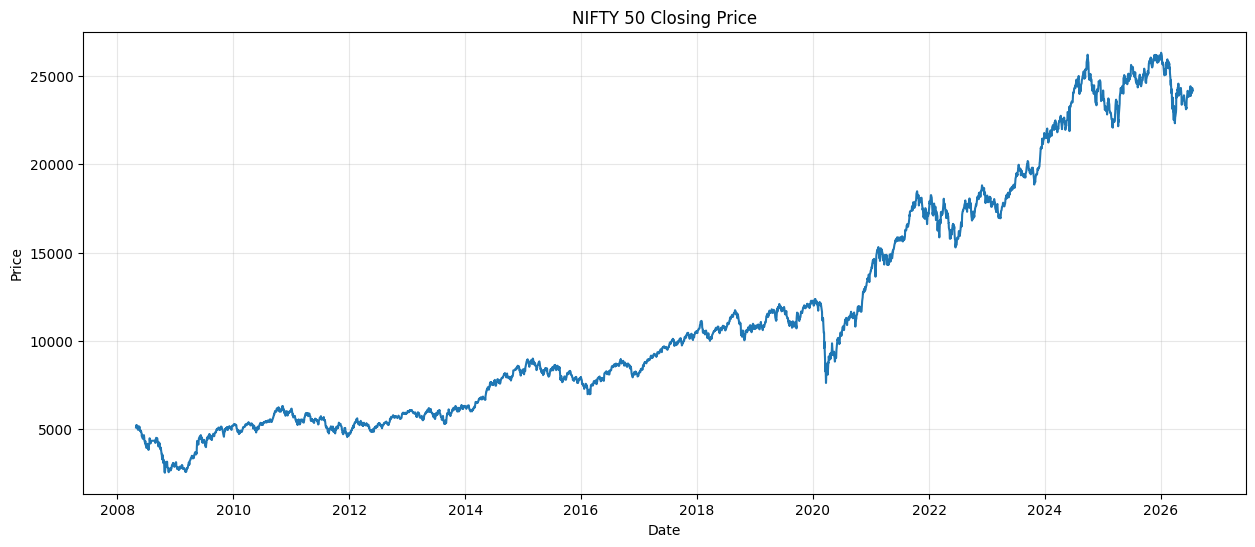

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    market_df.index,
    market_df["NIFTY_Close"],
    linewidth=1.5
)

plt.title("NIFTY 50 Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.grid(alpha=0.3)

plt.show()

### Observation

The NIFTY 50 closing price exhibits a strong long-term upward trend despite experiencing periods of significant volatility. Major market events, such as the 2008 Global Financial Crisis and the 2020 COVID-19 market crash, are visible as sharp declines, followed by sustained recoveries. This highlights the importance of incorporating trend, momentum, and volatility indicators into the feature engineering process, as raw closing prices alone do not fully capture the market dynamics required for reliable machine learning predictions.

## Price with Simple Moving Averages (SMA)

Simple Moving Averages smooth short-term price fluctuations and help identify the underlying market trend.

- **SMA 10** captures short-term momentum.
- **SMA 20** captures medium-term market direction.

When the price stays above both moving averages, it generally indicates bullish momentum, while trading below them may indicate weakness.

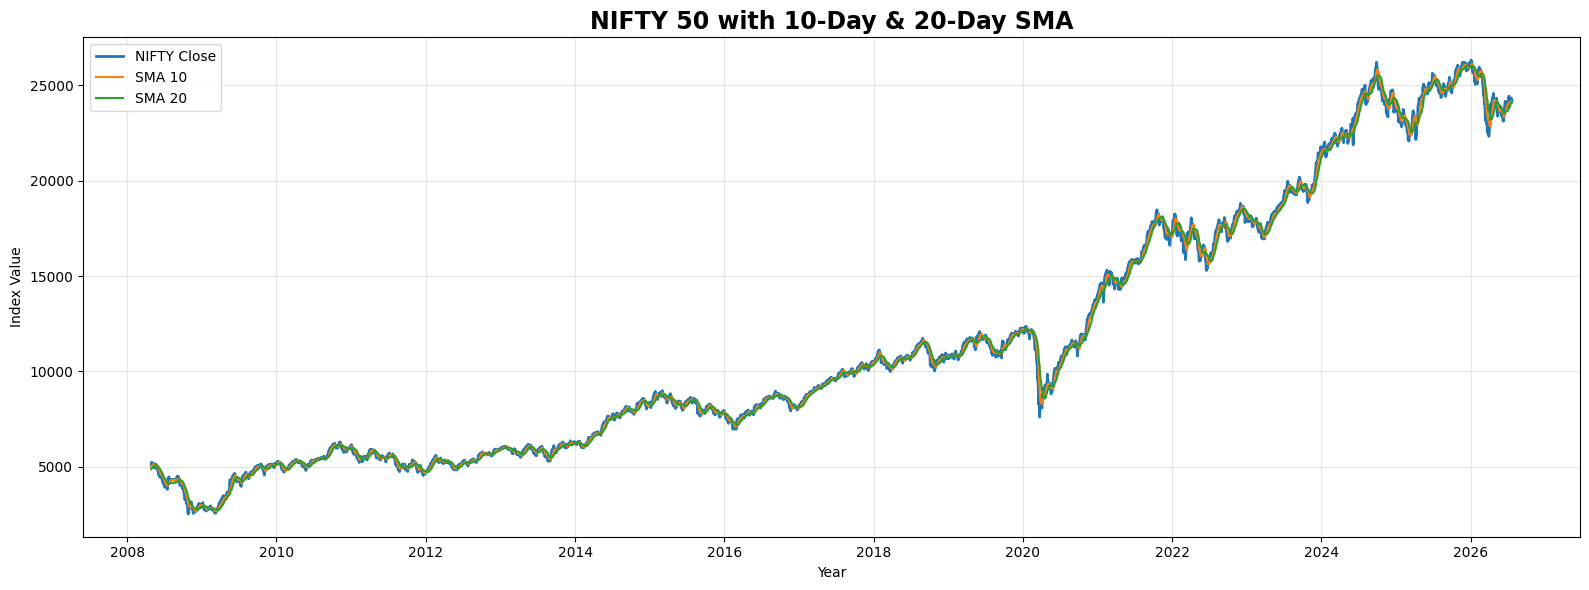

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    market_df.index,
    market_df["NIFTY_Close"],
    label="NIFTY Close",
    linewidth=2
)

plt.plot(
    market_df.index,
    market_df["NIFTY_SMA_10"],
    label="SMA 10",
    linewidth=1.5
)

plt.plot(
    market_df.index,
    market_df["NIFTY_SMA_20"],
    label="SMA 20",
    linewidth=1.5
)

plt.title("NIFTY 50 with 10-Day & 20-Day SMA", fontsize=17, weight="bold")

plt.xlabel("Year")
plt.ylabel("Index Value")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Price with Exponential Moving Averages (EMA)

Unlike SMA, the Exponential Moving Average gives greater importance to recent prices, allowing it to react faster to market movements.

This makes EMA particularly useful for identifying trend reversals and momentum shifts.

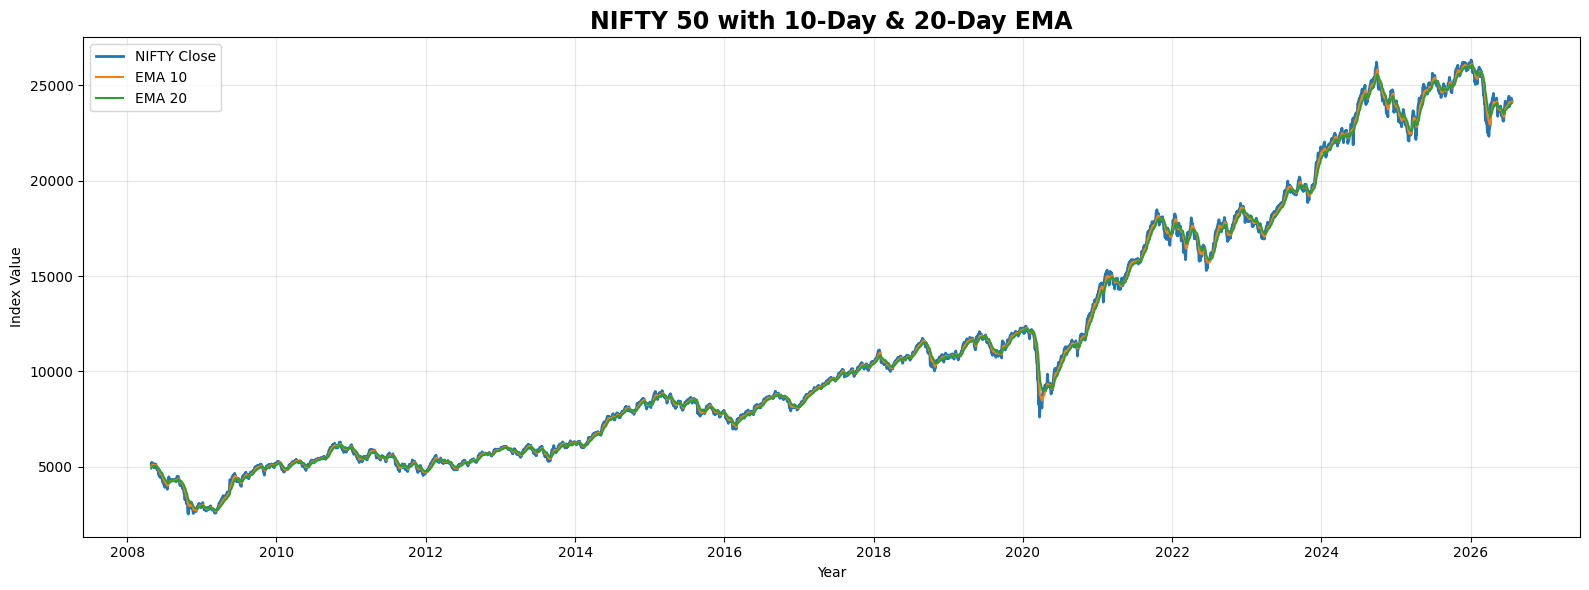

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    market_df.index,
    market_df["NIFTY_Close"],
    label="NIFTY Close",
    linewidth=2
)

plt.plot(
    market_df.index,
    market_df["NIFTY_EMA_10"],
    label="EMA 10",
    linewidth=1.5
)

plt.plot(
    market_df.index,
    market_df["NIFTY_EMA_20"],
    label="EMA 20",
    linewidth=1.5
)

plt.title("NIFTY 50 with 10-Day & 20-Day EMA", fontsize=17, weight="bold")

plt.xlabel("Year")
plt.ylabel("Index Value")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Relative Strength Index (RSI)

The Relative Strength Index is a momentum oscillator that measures the speed and magnitude of recent price movements.

Typical interpretation:

- RSI > 70 → Overbought
- RSI < 30 → Oversold

A 14-day window is used because it is the industry standard introduced by J. Welles Wilder.

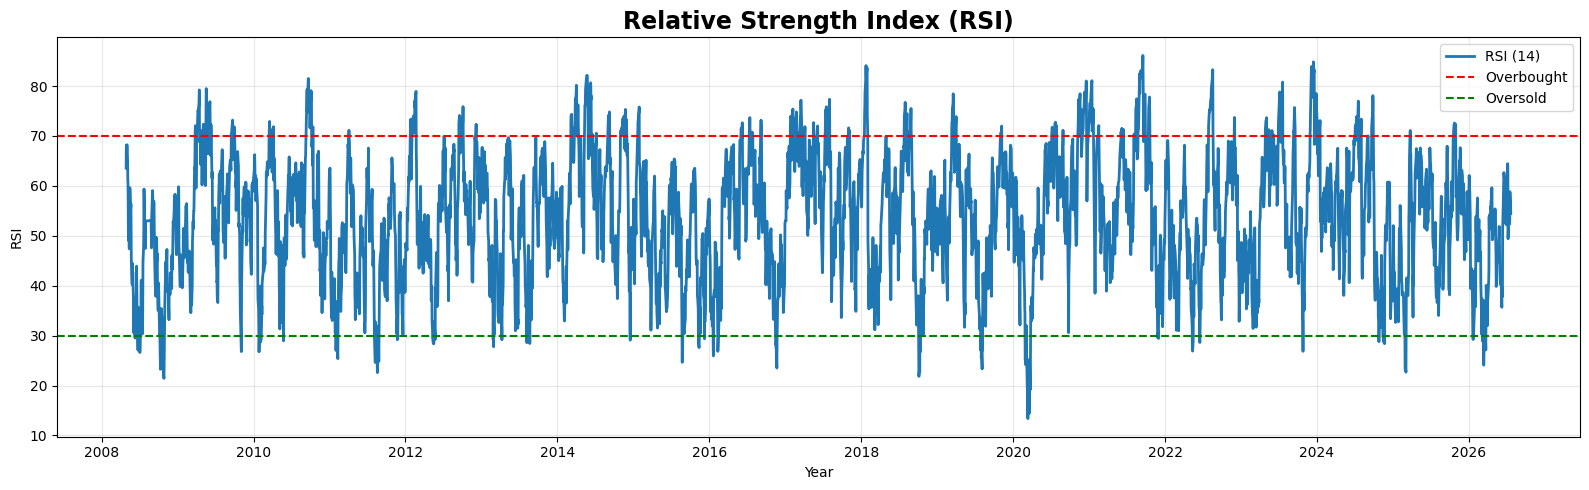

In [ ]:
plt.figure(figsize=(16,5))

plt.plot(
    market_df.index,
    market_df["RSI_14"],
    label="RSI (14)",
    linewidth=2
)

plt.axhline(
    70,
    color="red",
    linestyle="--",
    label="Overbought"
)

plt.axhline(
    30,
    color="green",
    linestyle="--",
    label="Oversold"
)

plt.title("Relative Strength Index (RSI)", fontsize=17, weight="bold")

plt.xlabel("Year")
plt.ylabel("RSI")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Moving Average Convergence Divergence (MACD)

The Moving Average Convergence Divergence (MACD) is a trend-following momentum indicator that measures the relationship between two exponential moving averages.

The MACD consists of:

- **MACD Line:** Difference between the 12-day and 26-day EMA.
- **Signal Line:** 9-day EMA of the MACD.
- **Histogram:** Difference between the MACD and Signal Line.

Crossovers between the MACD and Signal Line often indicate potential trend reversals or momentum shifts.

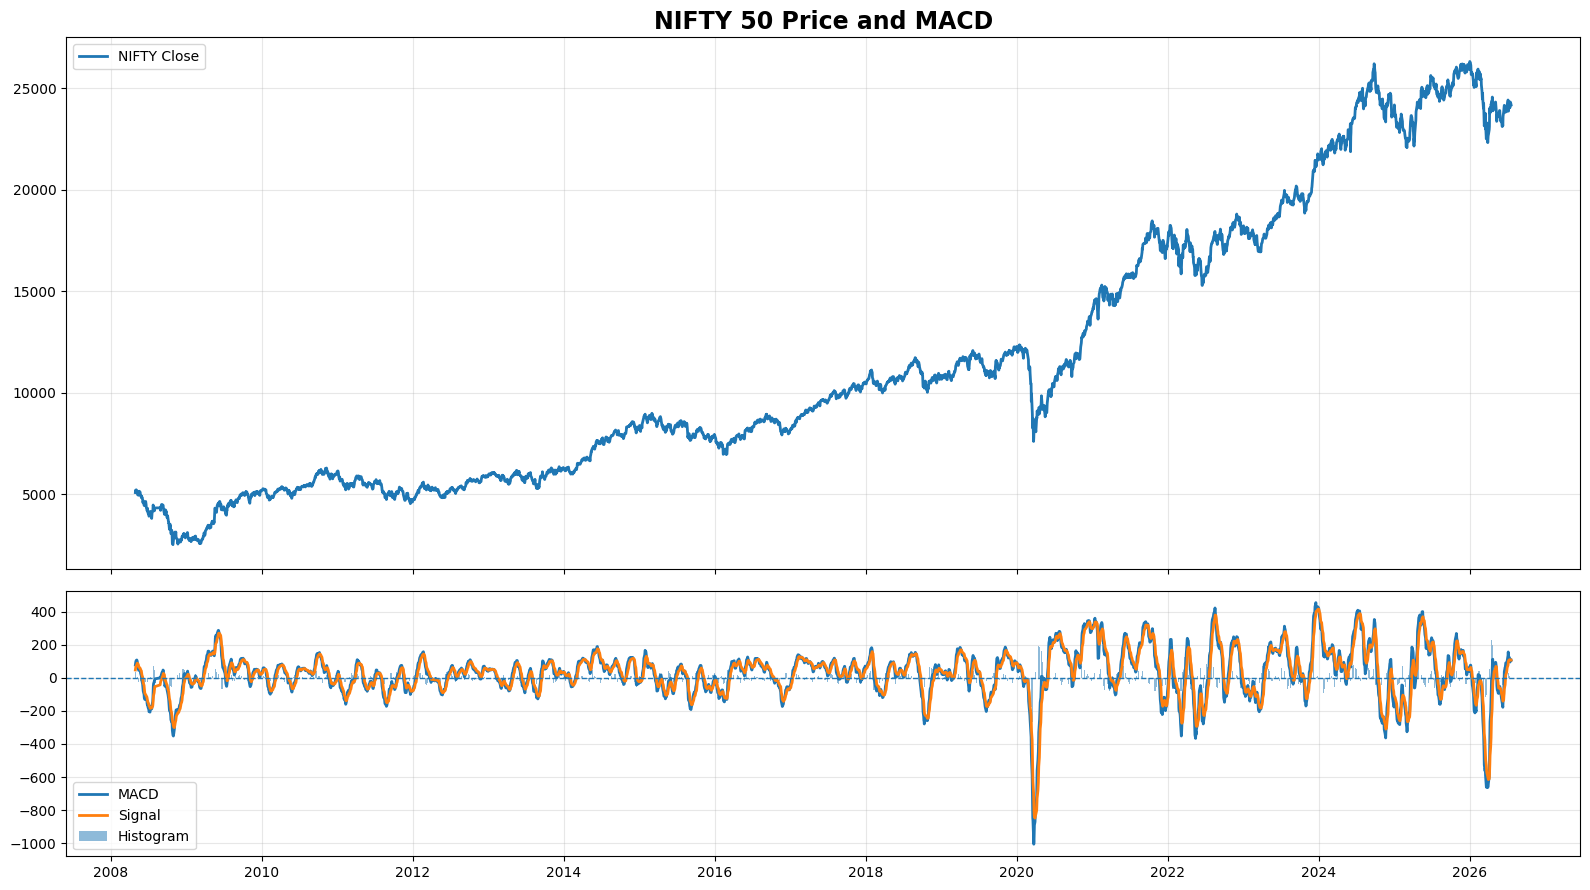

In [ ]:
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(16,9),
    sharex=True,
    gridspec_kw={"height_ratios":[2,1]}
)

# Price

ax1.plot(
    market_df.index,
    market_df["NIFTY_Close"],
    linewidth=2,
    label="NIFTY Close"
)

ax1.set_title(
    "NIFTY 50 Price and MACD",
    fontsize=17,
    weight="bold"
)

ax1.legend()

ax1.grid(alpha=0.3)

# MACD

ax2.plot(
    market_df.index,
    market_df["MACD"],
    label="MACD",
    linewidth=2
)

ax2.plot(
    market_df.index,
    market_df["MACD_Signal"],
    label="Signal",
    linewidth=2
)

ax2.bar(
    market_df.index,
    market_df["MACD_Histogram"],
    alpha=0.5,
    label="Histogram"
)

ax2.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax2.legend()

ax2.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Bollinger Bands

Bollinger Bands measure market volatility by placing upper and lower bands around a moving average.

The bands expand during periods of high volatility and contract during periods of low volatility.

When the price approaches the upper band, the market may be relatively overbought, while movement toward the lower band may indicate relatively oversold conditions.

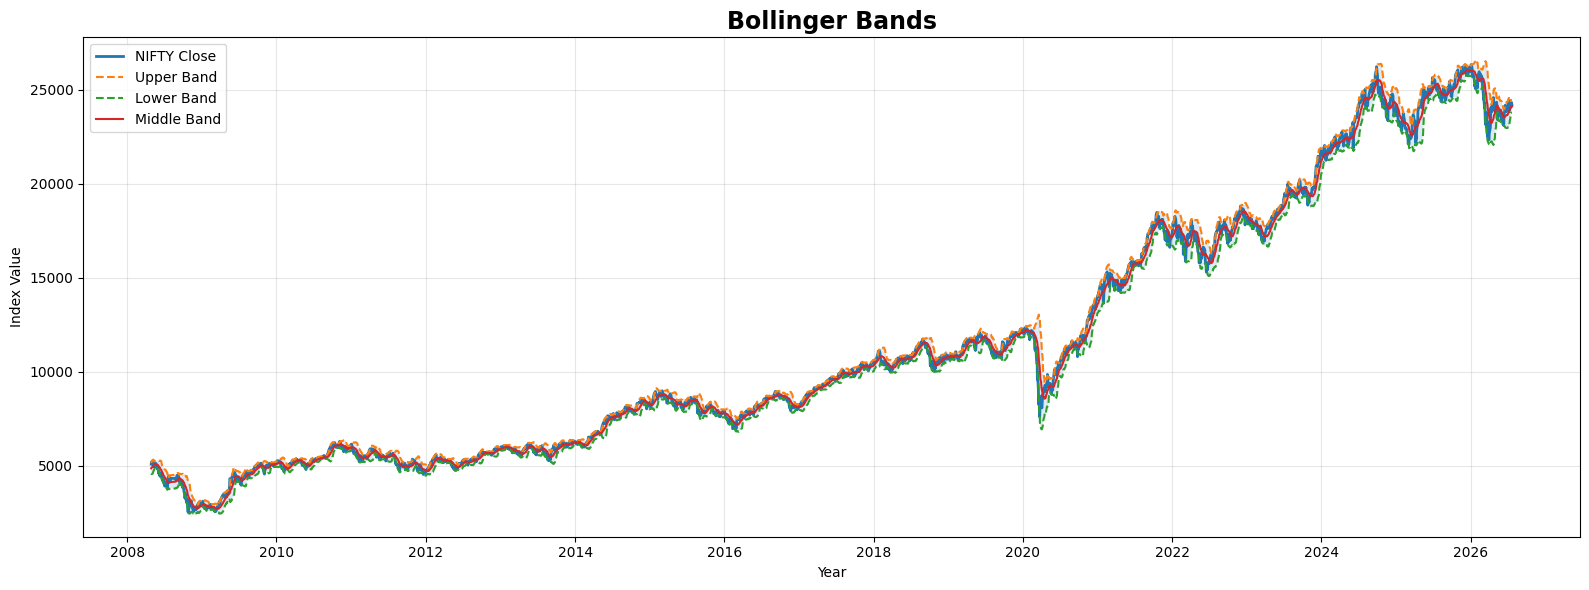

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    market_df.index,
    market_df["NIFTY_Close"],
    label="NIFTY Close",
    linewidth=2
)

plt.plot(
    market_df.index,
    market_df["BB_High"],
    linestyle="--",
    linewidth=1.5,
    label="Upper Band"
)

plt.plot(
    market_df.index,
    market_df["BB_Low"],
    linestyle="--",
    linewidth=1.5,
    label="Lower Band"
)

plt.plot(
    market_df.index,
    market_df["BB_Middle"],
    linewidth=1.5,
    label="Middle Band"
)

plt.fill_between(
    market_df.index,
    market_df["BB_High"],
    market_df["BB_Low"],
    alpha=0.15
)

plt.title(
    "Bollinger Bands",
    fontsize=17,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("Index Value")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Average True Range (ATR)

Average True Range (ATR) measures market volatility by calculating the average trading range over a fixed period.

Unlike trend indicators, ATR does not indicate market direction. Instead, it quantifies the magnitude of price movement, making it useful for assessing market risk and volatility.

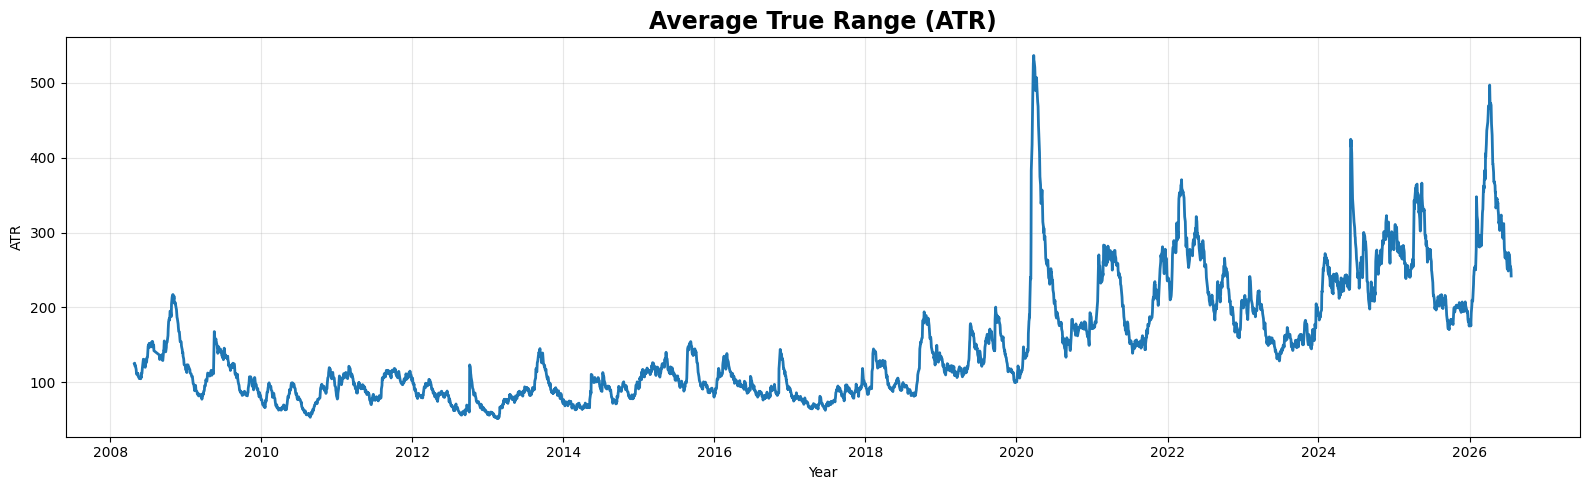

In [ ]:
plt.figure(figsize=(16,5))

plt.plot(
    market_df.index,
    market_df["ATR_14"],
    linewidth=2
)

plt.title(
    "Average True Range (ATR)",
    fontsize=17,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("ATR")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Rolling Volatility

Rolling Volatility represents the standard deviation of daily returns over a moving 20-day window.

Higher values indicate periods of increased market uncertainty, while lower values reflect relatively stable market conditions.

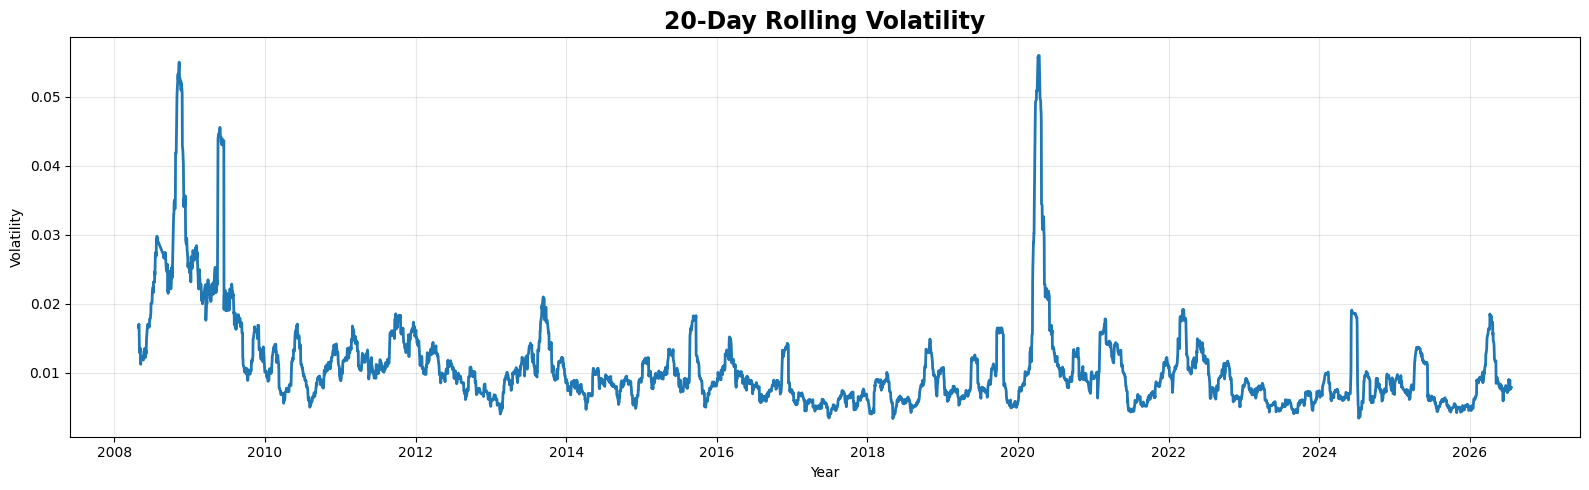

In [ ]:
plt.figure(figsize=(16,5))

plt.plot(
    market_df.index,
    market_df["Rolling_Volatility_20"],
    linewidth=2
)

plt.title(
    "20-Day Rolling Volatility",
    fontsize=17,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("Volatility")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Target Distribution

Before training machine learning models, it is important to inspect the class distribution of the target variable.

A balanced target distribution helps reduce prediction bias and provides a more reliable evaluation of classification models.

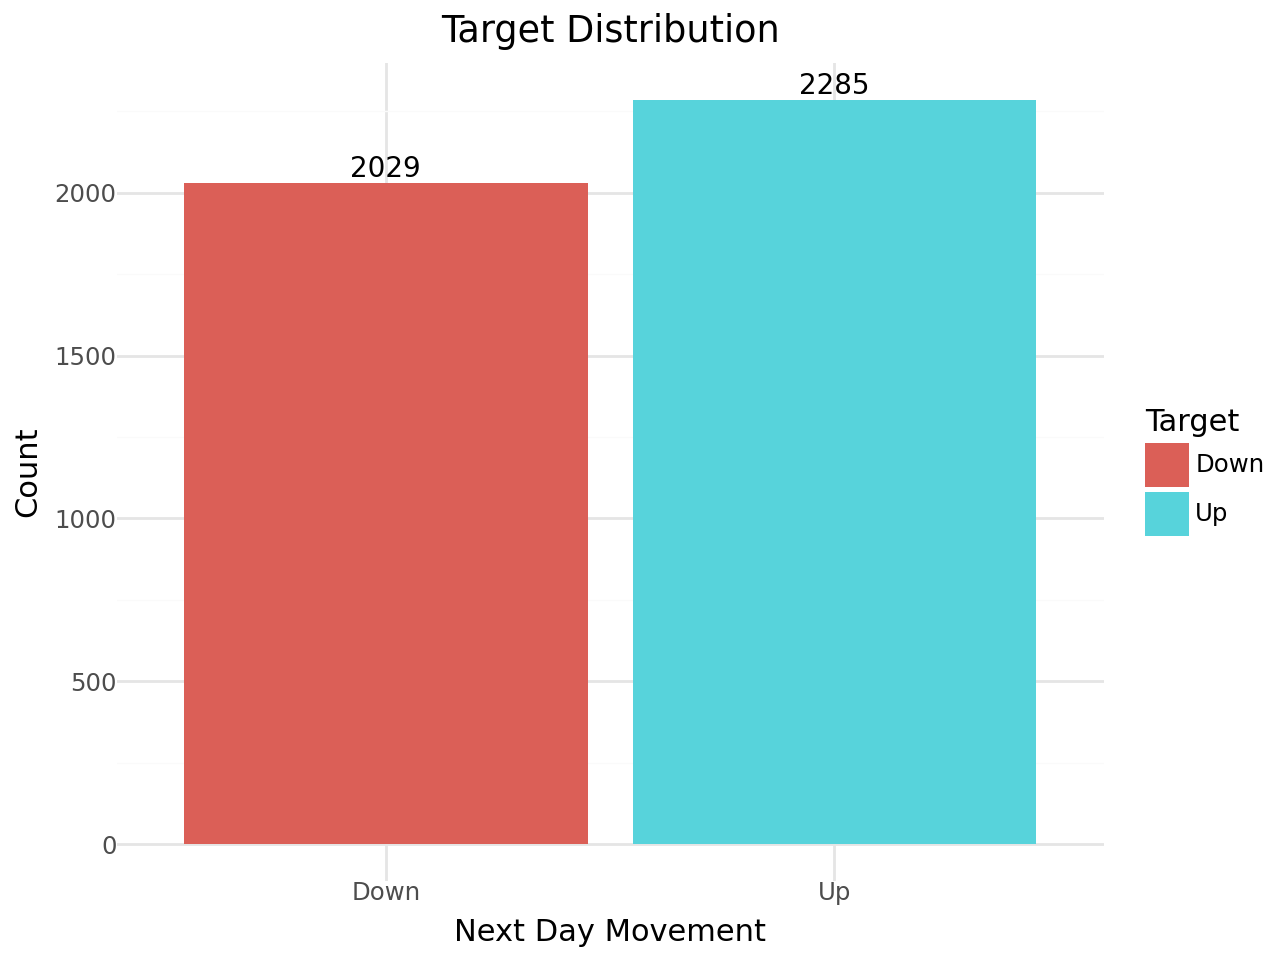

In [ ]:
target_df = (
    market_df["Target"]
    .value_counts()
    .rename_axis("Target")
    .reset_index(name="Count")
)

target_df["Target"] = target_df["Target"].map({
    0: "Down",
    1: "Up"
})

(
    ggplot(target_df, aes(x="Target", y="Count", fill="Target"))
    + geom_col()
    + geom_text(
        aes(label="Count"),
        va="bottom",
        size=10
    )
    + labs(
        title="Target Distribution",
        x="Next Day Movement",
        y="Count"
    )
    + theme_minimal()
)

## Daily Return Distribution

Daily returns describe the percentage change in the NIFTY 50 index from one trading day to the next.

Understanding the distribution of returns helps identify market volatility, extreme events, and the overall statistical characteristics of the dataset.

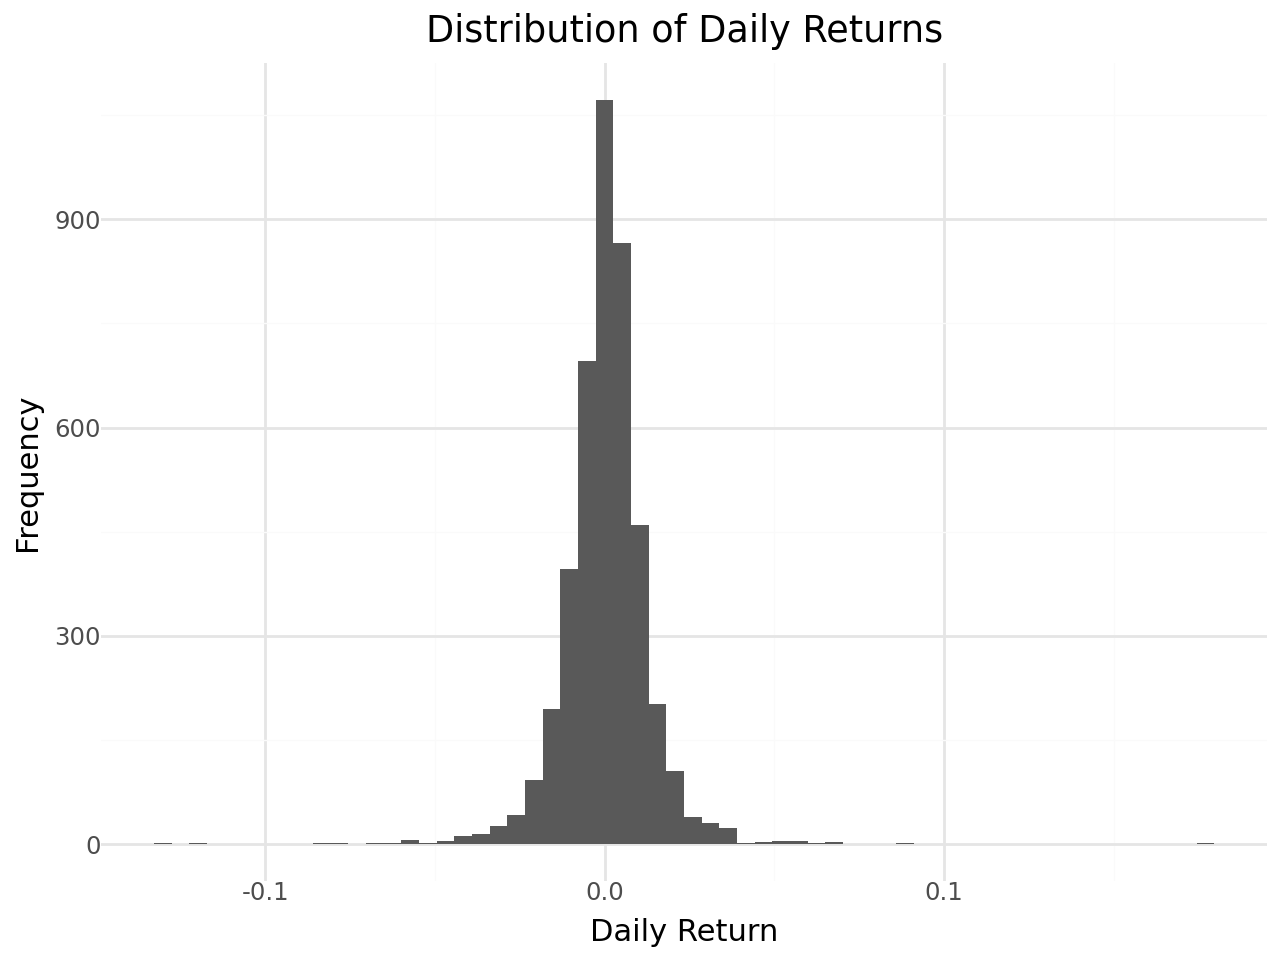

In [ ]:
(
    ggplot(
        market_df,
        aes(x="NIFTY_Return")
    )
    + geom_histogram(
        bins=60
    )
    + labs(
        title="Distribution of Daily Returns",
        x="Daily Return",
        y="Frequency"
    )
    + theme_minimal()
)

## Correlation Matrix

The correlation matrix illustrates the linear relationships between engineered features.

Highly correlated variables may contain redundant information, while weakly correlated features often contribute complementary information to machine learning models.

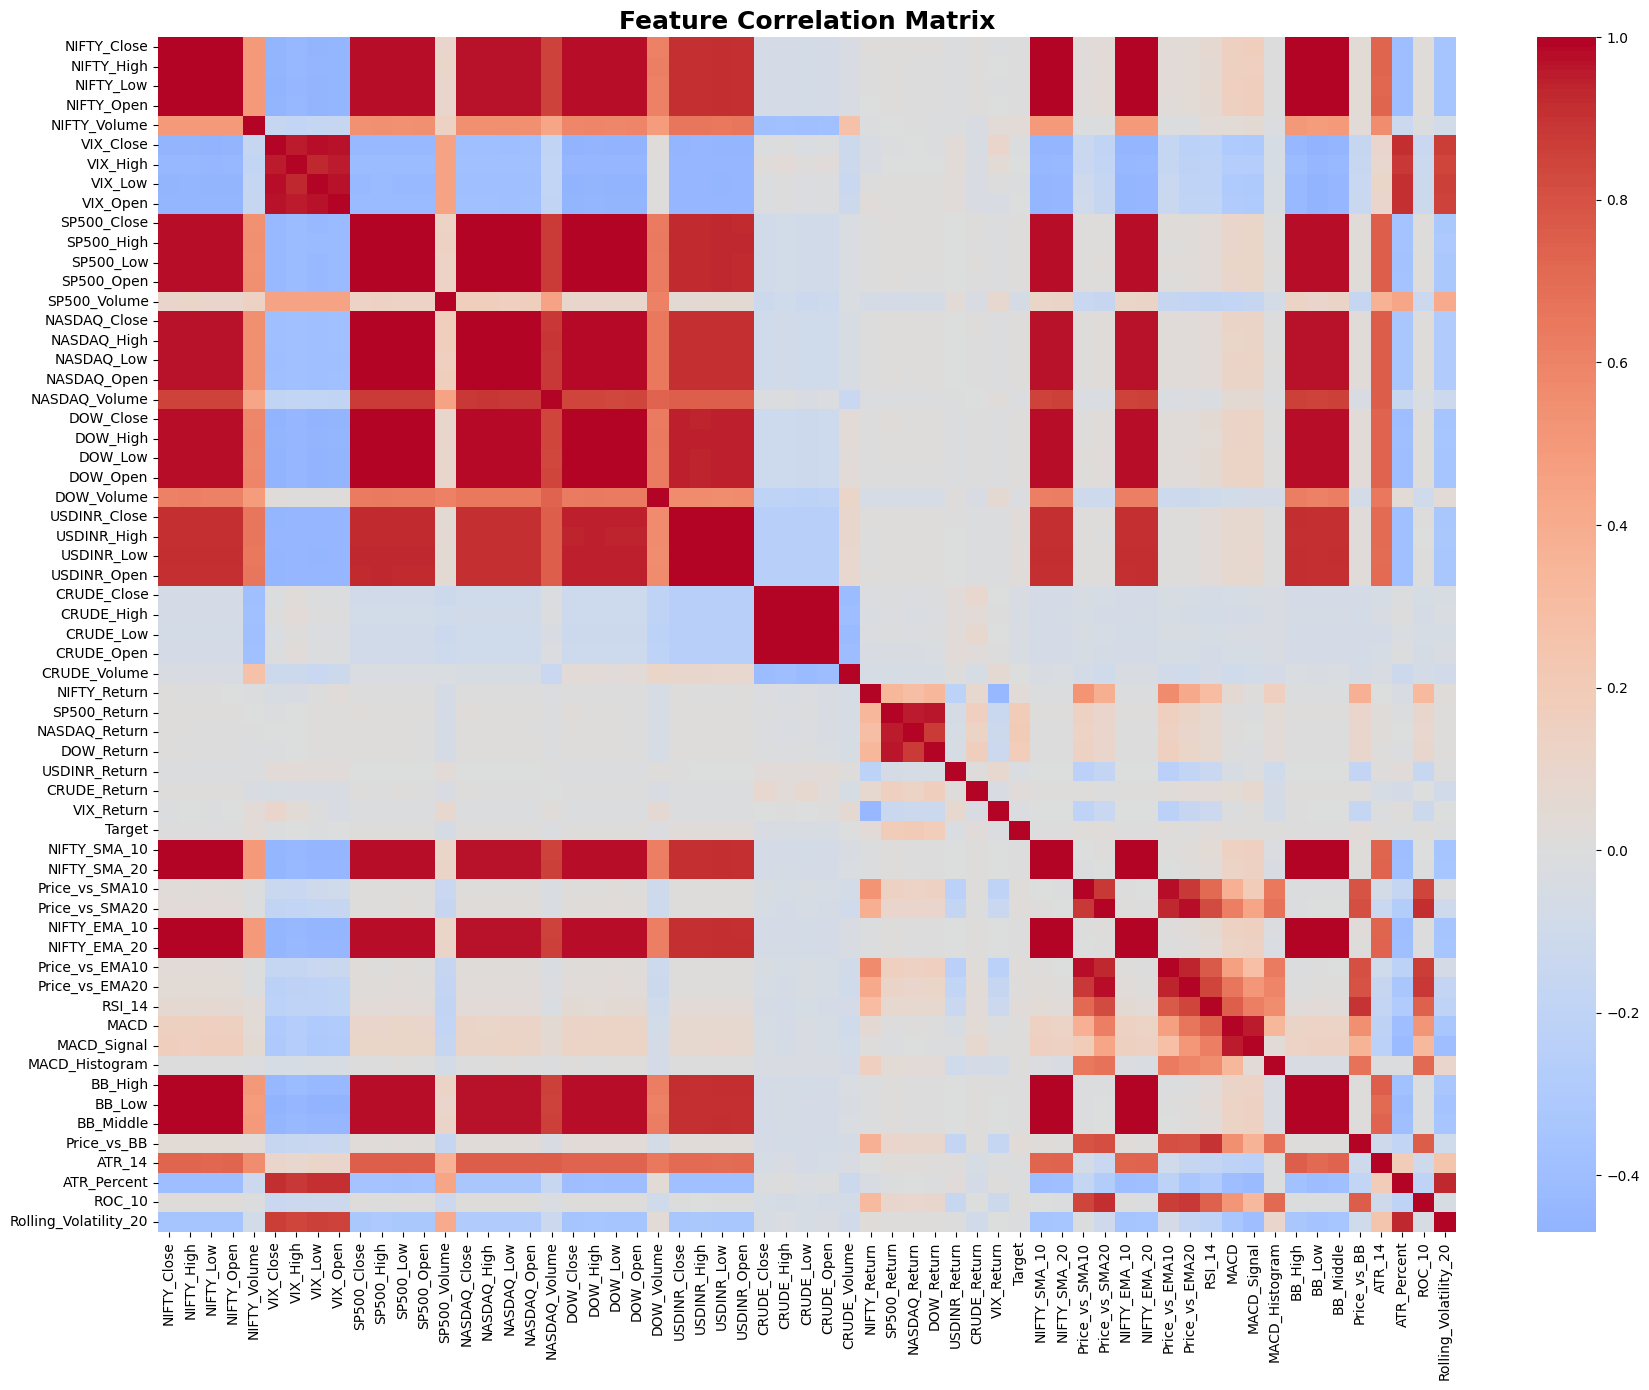

In [ ]:
plt.figure(figsize=(18,14))

sns.heatmap(
    market_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title(
    "Feature Correlation Matrix",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()

plt.show()

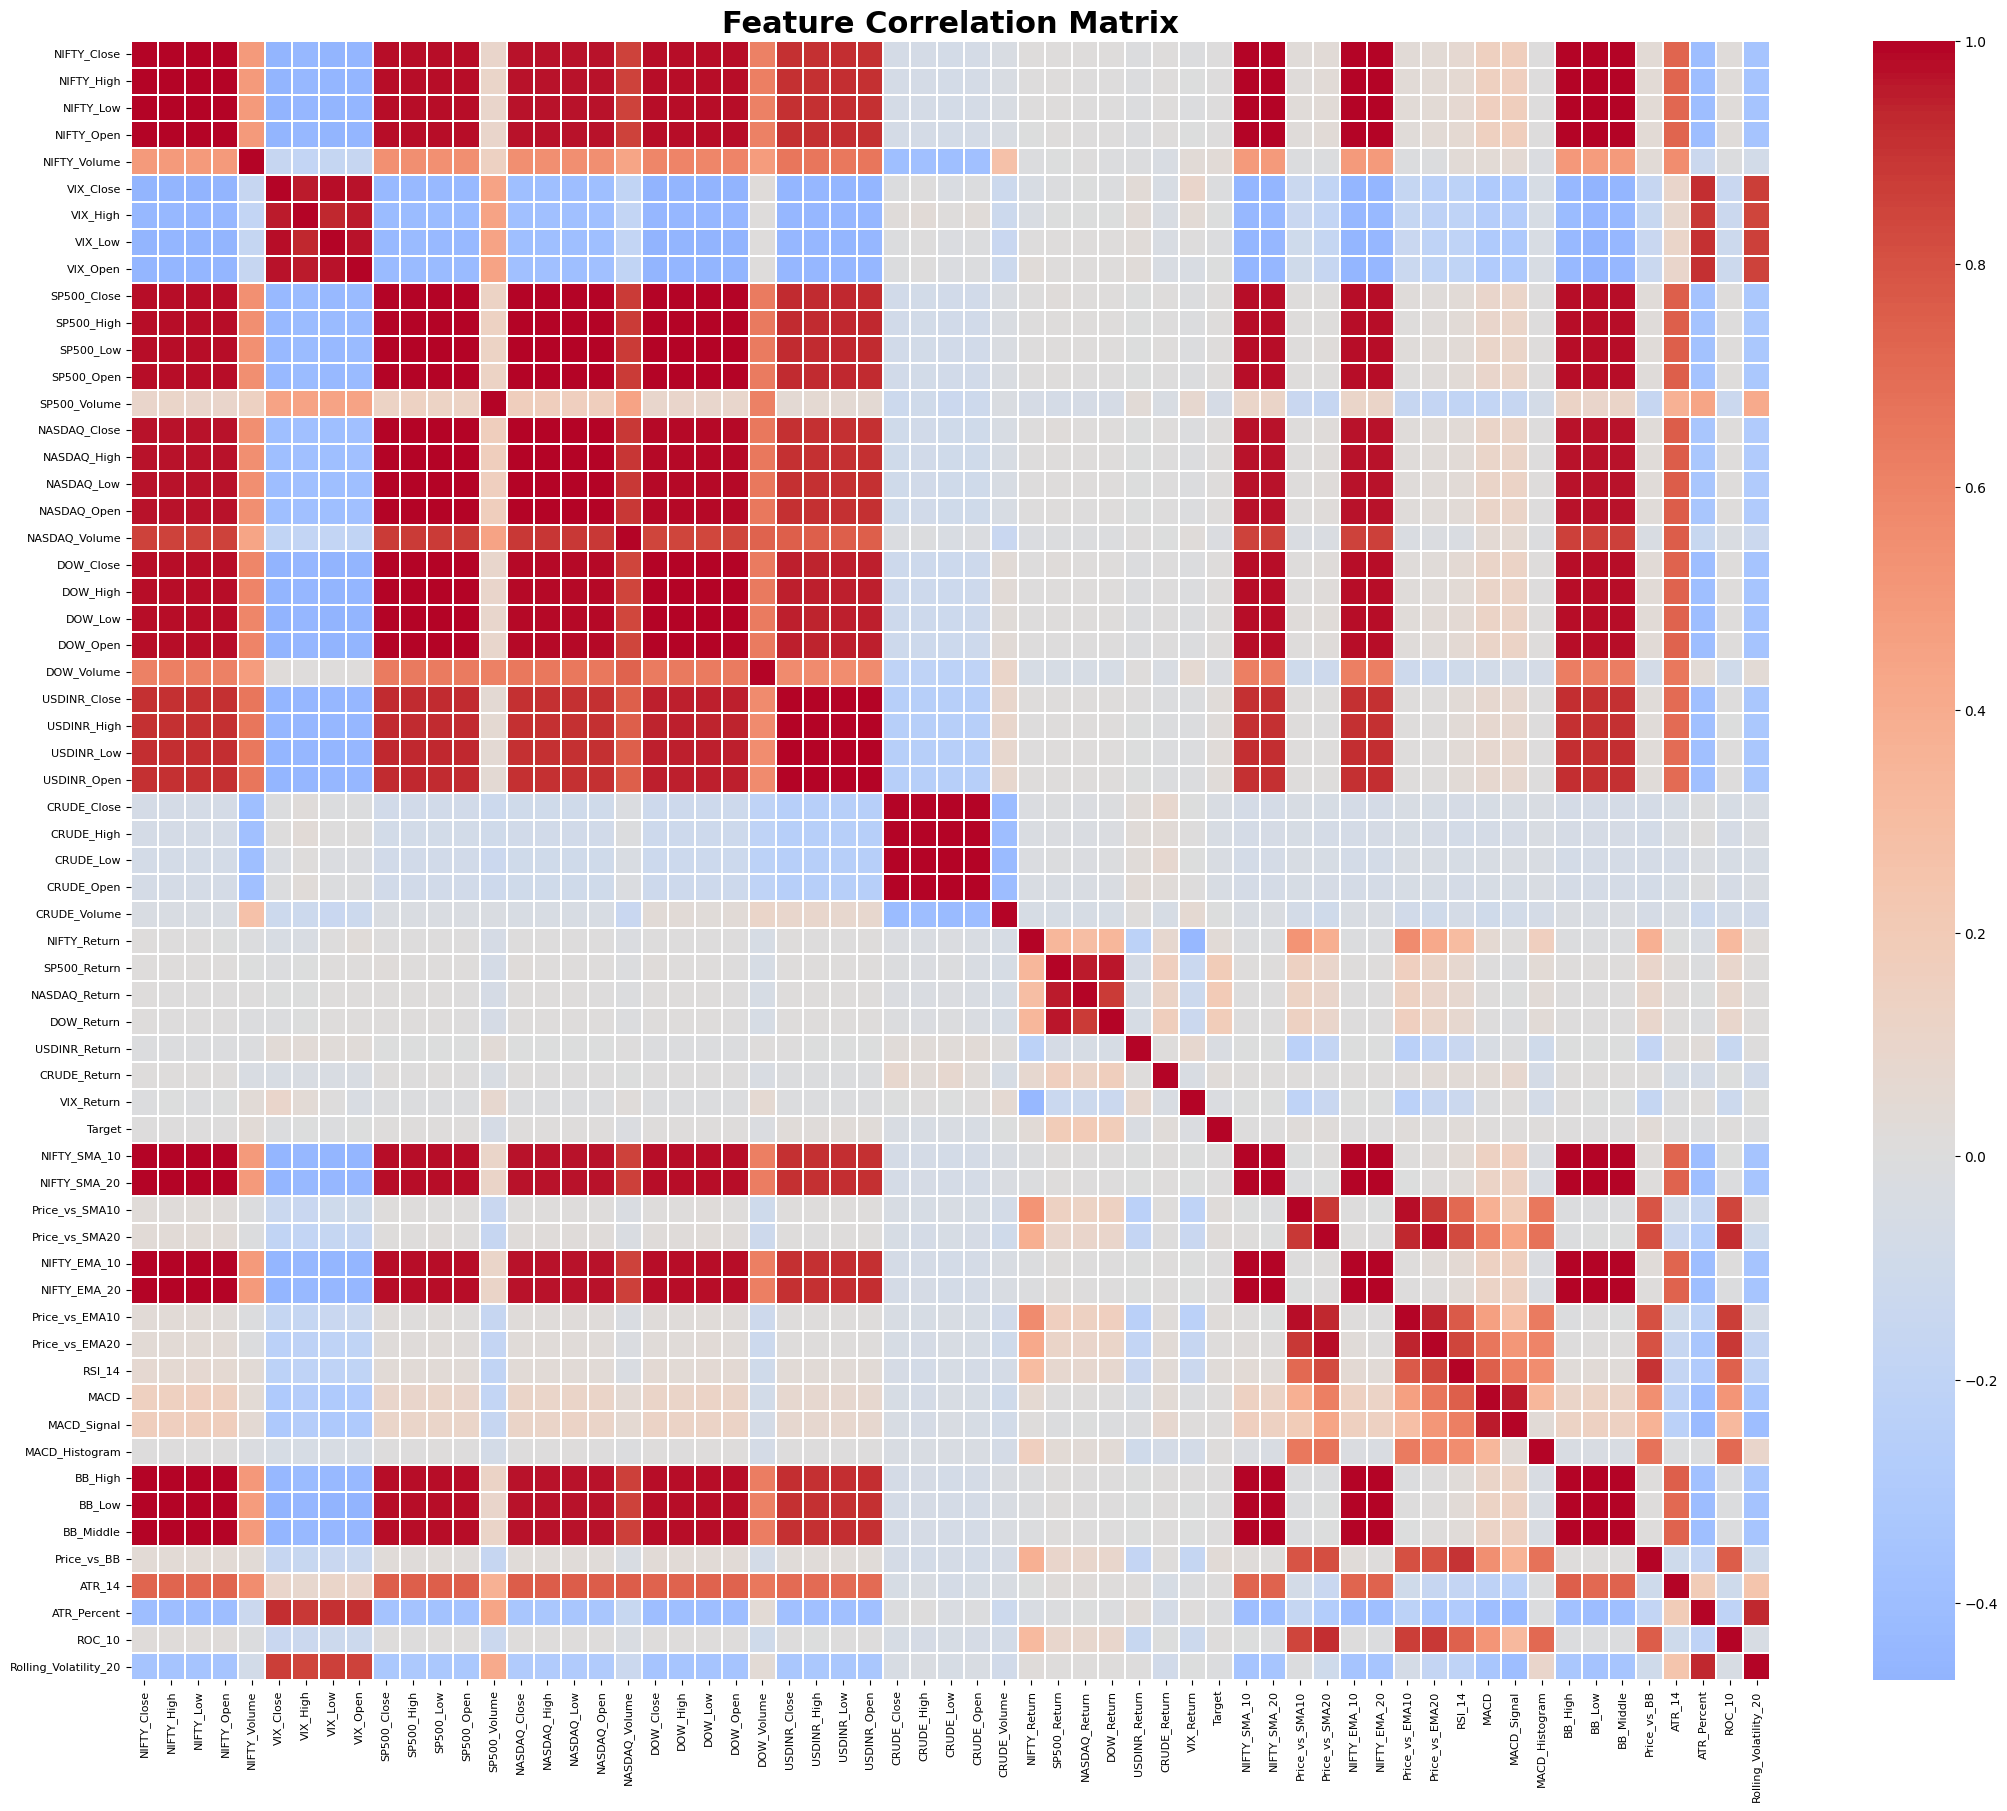

In [ ]:
plt.figure(figsize=(22,18))

sns.heatmap(
    market_df.corr(),
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2
)

plt.title(
    "Feature Correlation Matrix",
    fontsize=22,
    weight="bold"
)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()

plt.show()

### Observation

The correlation matrix highlights several meaningful relationships among the engineered features. Price-based variables and their moving averages exhibit strong positive correlations, reflecting their shared dependence on market trends. Volatility-related indicators, such as the VIX, ATR, and Rolling Volatility, display distinct correlation patterns, providing complementary information beyond raw price movements. Return-based features are comparatively less correlated with price levels, suggesting they capture short-term market dynamics rather than long-term trends. These observations indicate that the engineered feature set contains both trend-following and volatility-sensitive information, improving the diversity of inputs available for machine learning models.

# Machine Learning Model Evaluation

This section evaluates the performance of the trained machine learning models using multiple classification metrics.

The comparison includes:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score
- Training Time

In addition, model interpretability techniques such as Feature Importance and SHAP values are used to understand how individual features contribute to model predictions.

In [ ]:
results = {
    "Logistic Regression ": logistic_results,
    "LightGBM V3 (Selected Features)": lgbm_v3_results,
    "CatBoost V3 (Selected Features - Second Tuned)": catboost_v3_results,
    "XGBoost V3 (Selected Features - Second Tuned)": xgb_v3_results
}

results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Train Time (s),Prediction Time (s)
Logistic Regression,0.538251,0.524823,0.808743,0.636559,0.554899,0.115065,0.000432
LightGBM V3 (Selected Features),0.549180,0.576271,0.371585,0.451827,0.564394,0.936528,0.025307
CatBoost V3 (Selected Features - Second Tuned),0.568306,0.592593,0.437158,0.503145,0.592822,3.985914,0.001929
XGBoost V3 (Selected Features - Second Tuned),0.584699,0.596273,0.524590,0.558140,0.593658,3.162790,0.008256


## Model Performance Comparison

The following visualizations compare the performance of all trained machine learning models using three key metrics:

- **Accuracy:** Overall prediction performance.
- **ROC-AUC:** Ability to distinguish between upward and downward market movements.
- **Training Time:** Computational efficiency of each algorithm.

These metrics provide a balanced comparison between predictive performance and computational cost.

/tmp/ipykernel_1980/147530176.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



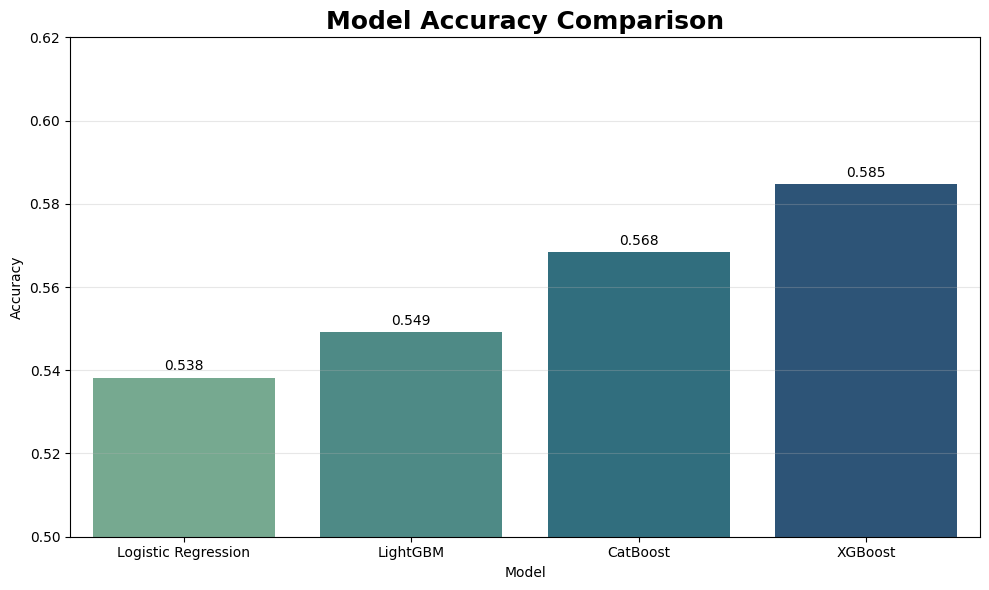

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=plot_df,
    x=plot_df.index,
    y="Accuracy",
    palette="crest"
)

plt.title(
    "Model Accuracy Comparison",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0.50,0.62)

plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=10
    )

plt.tight_layout()

plt.show()

/tmp/ipykernel_1980/2894124870.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



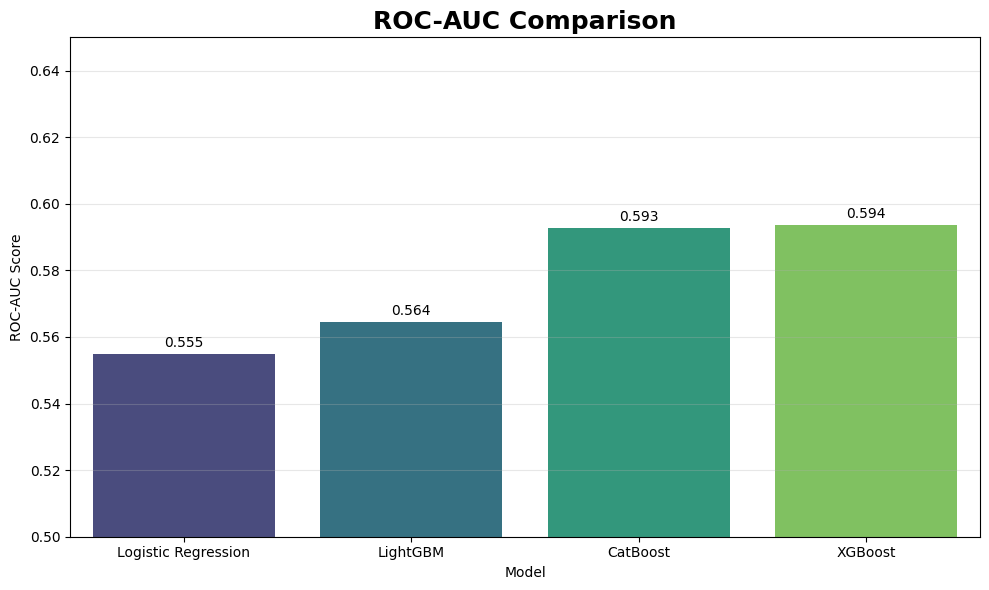

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=plot_df,
    x=plot_df.index,
    y="ROC-AUC",
    palette="viridis"
)

plt.title(
    "ROC-AUC Comparison",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Model")
plt.ylabel("ROC-AUC Score")

plt.ylim(0.50,0.65)

plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=10
    )

plt.tight_layout()

plt.show()

/tmp/ipykernel_1980/2139372769.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



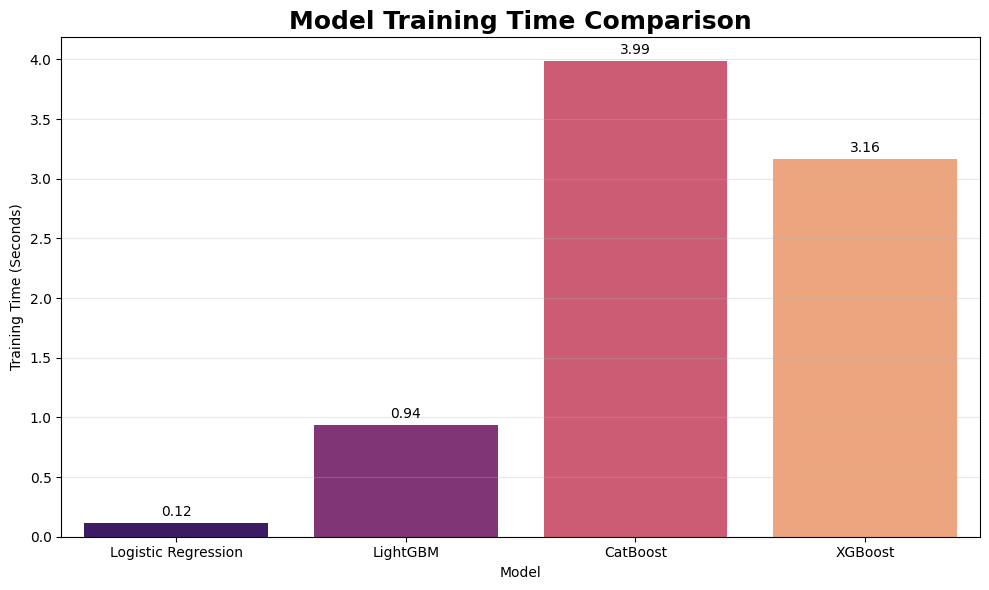

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=plot_df,
    x=plot_df.index,
    y="Train Time (s)",
    palette="magma"
)

plt.title(
    "Model Training Time Comparison",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Model")
plt.ylabel("Training Time (Seconds)")

plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=10
    )

plt.tight_layout()

plt.show()

In [ ]:
comparison_table = (
    plot_df[
        ["Accuracy","Precision","Recall","F1 Score","ROC-AUC","Train Time (s)"]
    ]
    .sort_values(
        by="Accuracy",
        ascending=False
    )
)

comparison_table.style\
.background_gradient(cmap="YlGnBu")\
.format("{:.3f}")

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Train Time (s)
XGBoost,0.585,0.596,0.525,0.558,0.594,3.163
CatBoost,0.568,0.593,0.437,0.503,0.593,3.986
LightGBM,0.549,0.576,0.372,0.452,0.564,0.937
Logistic Regression,0.538,0.525,0.809,0.637,0.555,0.115


## Confusion Matrix

A confusion matrix summarizes the classification performance by comparing the predicted labels with the true labels.

It provides insight into the number of correct and incorrect predictions, allowing the identification of false positives and false negatives in addition to overall accuracy.

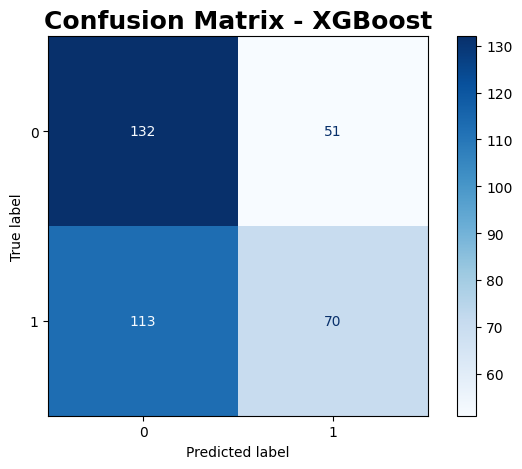

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_test_v3,
    y_test,
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Confusion Matrix - XGBoost",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()

plt.show()

## Receiver Operating Characteristic (ROC) Curve

The Receiver Operating Characteristic (ROC) Curve evaluates the classification performance across different probability thresholds.

The Area Under the Curve (ROC-AUC) measures the model's ability to distinguish between upward and downward market movements. A higher ROC-AUC indicates better discriminative performance.

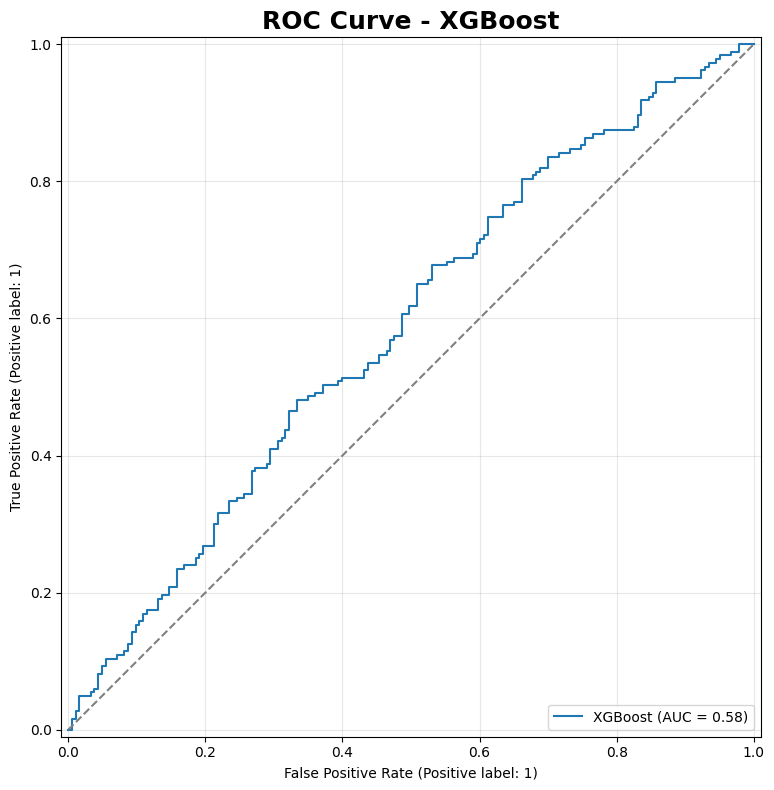

In [ ]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,8))

RocCurveDisplay.from_estimator(
    xgb_model,
    X_test_v3,
    y_test,
    name="XGBoost",
    ax=plt.gca()
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.title(
    "ROC Curve - XGBoost",
    fontsize=18,
    weight="bold"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Feature Importance

Feature importance identifies which variables contribute the most to the model's predictions.

Understanding feature importance helps interpret the model and highlights the most influential market indicators used for predicting the next day's market direction.

<Figure size 1000x1000 with 0 Axes>

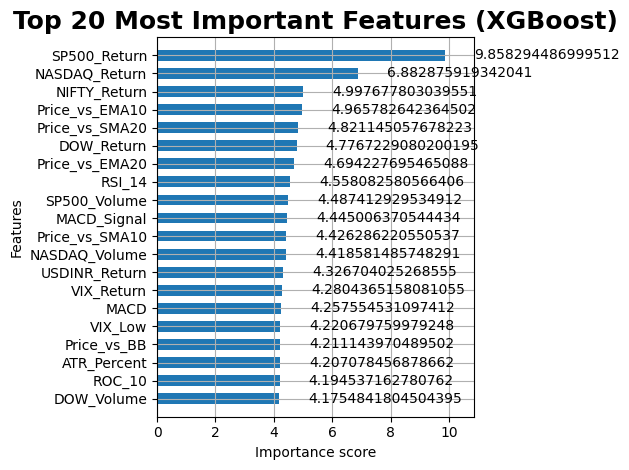

In [ ]:
from xgboost import plot_importance

plt.figure(figsize=(10,10))

plot_importance(
    xgb_model,
    max_num_features=20,
    importance_type="gain",
    height=0.6
)

plt.title(
    "Top 20 Most Important Features (XGBoost)",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()

plt.show()